# Projeto Final: Aplicação de Algoritmos para compreender a difusão de *fake news*

**Aluna:** Mariana Melo Pereira

**Orientador:** Prof. Dr. Felipe David Castro de Lima

Este Notebook é o resultado final do projeto que propõe o uso do Algoritmo de Metrópolis e do Modelo de Ising, tradicionalmente utilizados na física estatística, para simular a disseminação de fake news em populações, cada uma com suas variáveis de influência. Os indivíduos são representados como um spin, com duas possíveis opiniões: acreditar (+1) ou não acreditar (−1) na informação disseminada.

A dinâmica de mudança de opinião é regida de tal forma que os indivíduos mudam de estado, a depender da influência de seus vizinhos e do parâmetro de temperatura social, que será melhor explicado adiante. Esse parâmetro controla o nível de aleatoriedade nas decisões: temperaturas baixas favorecem o conformismo, enquanto temperaturas altas promovem diversidade de opinião.

O modelo também incorpora líderes de opinião (ou hubs), que mantêm suas crenças fixas (favoráveis ou contrárias às fake news) e exercem forte influência sobre os demais. Portanto, a simulação oferece uma ferramenta poderosa para entender os mecanismos sociais por trás da propagação de narrativas falsas e pode auxiliar no desenvolvimento de estratégias para entender e, até mesmo, reduzir seus efeitos.

## Perguntas a serem respondidas:
- Como o consenso se forma ou se desfaz?
- Qual o impacto da temperatura social na estabilidade das crenças?
- Qual o papel de líderes crentes, céticos ou mistos na propagação, redução ou controle da desinformação?

---

#### Observações:
Para as simulações deste Notebook, foi adotado como padrão:
- Nós **vermelhos acreditam** nas fake news
- Nós **azuis não acreditam** nas fake news

## - Método 1: Algoritmo de Metrópolis

O **Algoritmo de Metrópolis** é um método de amostragem estocástica usado para gerar amostras de uma distribuição de probabilidade complexa, especialmente quando a distribuição é difícil de amostrar diretamente. 
Ele é a base do método mais geral conhecido como **Método de Monte Carlo via Cadeias de Markov (MCMC)**.

A ideia desse método é construir uma cadeia de Markov cuja distribuição estacionária seja a distribuição alvo ($\pi$). Com o tempo, as amostras geradas pela cadeia convergem para essa distribuição.

---

### Passos do Algoritmo de Metrópolis

Dado que queremos amostrar de uma distribuição ($\pi$), devemos:

1. **Inicialização**: Escolher um ponto inicial $x_0$.
2. **Proposta**: Gerar um novo ponto candidato $x'$ a partir de uma distribuição de proposta $q(x'|x_t)$.
3. **Aceitação**:
   - Calcular a razão de aceitação:
     $$
     \alpha = \min\left(1, \frac{\pi(x')}{\pi(x_t)}\right)
     $$
   - Aceitar $x'$ como o próximo estado $x_{t+1}$ com probabilidade $\alpha$; caso contrário, manter $x_{t+1} = x_t$.
4. **Iteração**: Repitir os passos 2 e 3 por um número desejado de iterações.

> Obs: No algoritmo original de Metrópolis, a distribuição de proposta $q$ é simétrica, ou seja, $q(x'|x) = q(x|x')$, o que simplifica a razão de aceitação.

---
### Aplicações
- Física estatística (onde o algoritmo foi originalmente desenvolvido)
- Inferência Bayesiana
- Otimização estocástica
- Geração de amostras para integrais de Monte Carlo

---


Podemos também aplicar o **algoritmo de Metrópolis** para analisar a **difusão de fake news**. A ideia é modelar a propagação de informações (verdadeiras ou falsas) como um processo estocástico em uma rede social, onde o algoritmo ajuda a simular ou inferir padrões de disseminação.

---

### Como aplicar o algoritmo de Metrópolis nesse contexto

#### 1. **Modelagem da Rede (grafo)**
- Cada **nó** representa um usuário.
- Cada **aresta** representa uma conexão (amizade, seguidores, etc.).
- Cada nó pode estar em um estado: **acreditando** ou **não acreditando** na fake news.

#### 2. **Definir a Função de Energia (ou Custo)**
- A função de energia $E(x)$ mede o "custo" de um determinado estado da rede.
- Pode ser baseada em:
  - Número de usuários que acreditam na fake news.
  - Influência dos usuários (ex: seguidores).
  - Conformidade com vizinhos (usuários tendem a acreditar se seus amigos acreditam).

#### 3. **Distribuição Alvo**
- A distribuição $\pi(x) \propto e^{-E(x)}$ representa a probabilidade de um estado da rede.
- Estados com menor energia (mais coerentes com o comportamento social) são mais prováveis.

#### 4. **Aplicação do Algoritmo**
- Comece com um estado inicial da rede (ex: poucos usuários acreditando).
- Proponha uma mudança (ex: um usuário muda de opinião).
- Calcule a nova energia e decida se aceita a mudança com base na razão de aceitação de Metrópolis.

#### 5. **Simulação**
- Após várias iterações, poderemos observar:
  - Como a fake news se espalha.
  - Quais usuários são mais influentes.
  - Quais configurações levam à contenção da fake news.

---

### Possíveis Aplicações Práticas

- **Simular cenários de intervenção**: O que acontece se certos usuários forem alertados?
- **Avaliar políticas de moderação**: Como a remoção de certos nós (usuários) afeta a propagação?
- **Inferência de parâmetros sociais**: Como o comportamento coletivo influencia a aceitação de fake news?

---

## Implementando o Modelo Computacional

#### Importação das bibliotecas

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

#### Parâmetros para simulação

In [90]:
# Parâmetros da simulação
num_users = 100
num_iterations = 1000

# Parâmetros sobre os líderes
num_leaders = int(0.05 * num_users)
leader_fraction = 0.05

### Teste 1: população sem líderes

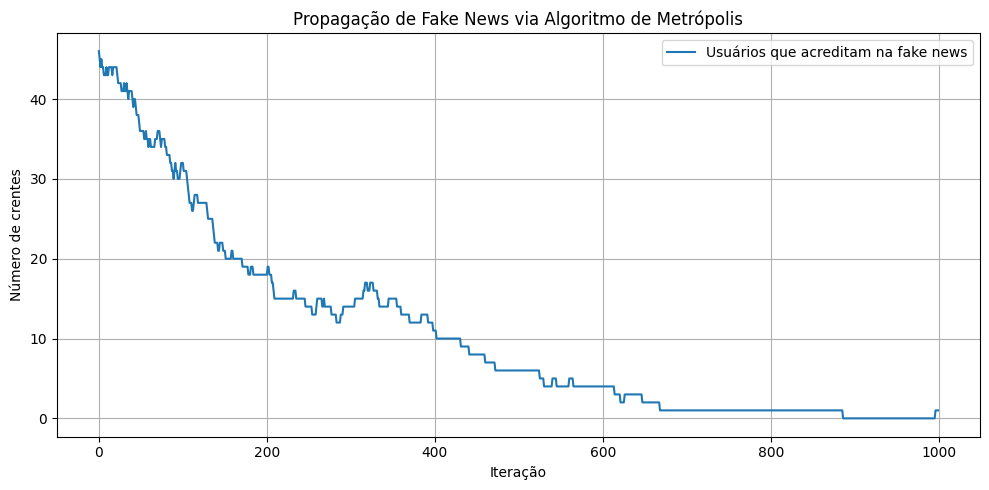

In [93]:
# Criar uma rede social aleatória
G = nx.erdos_renyi_graph(n=num_users, p=0.05)

# Estado inicial: 0 = não acredita, 1 = acredita
state = {node: random.choice([0, 1]) for node in G.nodes()}

# Função de energia: usuários tendem a imitar seus vizinhos
def energy(state, G):
    E = 0
    for node in G.nodes():
        for neighbor in G.neighbors(node):
            if state[node] != state[neighbor]:
                E += 1  # penalidade por discordância
    return E

# Algoritmo de Metrópolis
belief_counts = []
for _ in range(num_iterations):
    # Escolher um nó aleatório
    node = random.choice(list(G.nodes()))
    
    # Propor mudança de estado
    new_state = state.copy()
    new_state[node] = 1 - new_state[node]  # inverte crença
    
    # Calcular energias
    E_current = energy(state, G)
    E_new = energy(new_state, G)
    
    # Razão de aceitação
    delta_E = E_new - E_current
    if delta_E < 0 or random.random() < np.exp(-delta_E):
        state = new_state  # aceita nova configuração
    
    # Registrar número de usuários que acreditam na fake news
    belief_counts.append(sum(state.values()))

# Visualizar evolução da crença ao longo do tempo
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, label='Usuários que acreditam na fake news')
plt.xlabel('Iteração')
plt.ylabel('Número de crentes')
plt.title('Propagação de Fake News via Algoritmo de Metrópolis')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

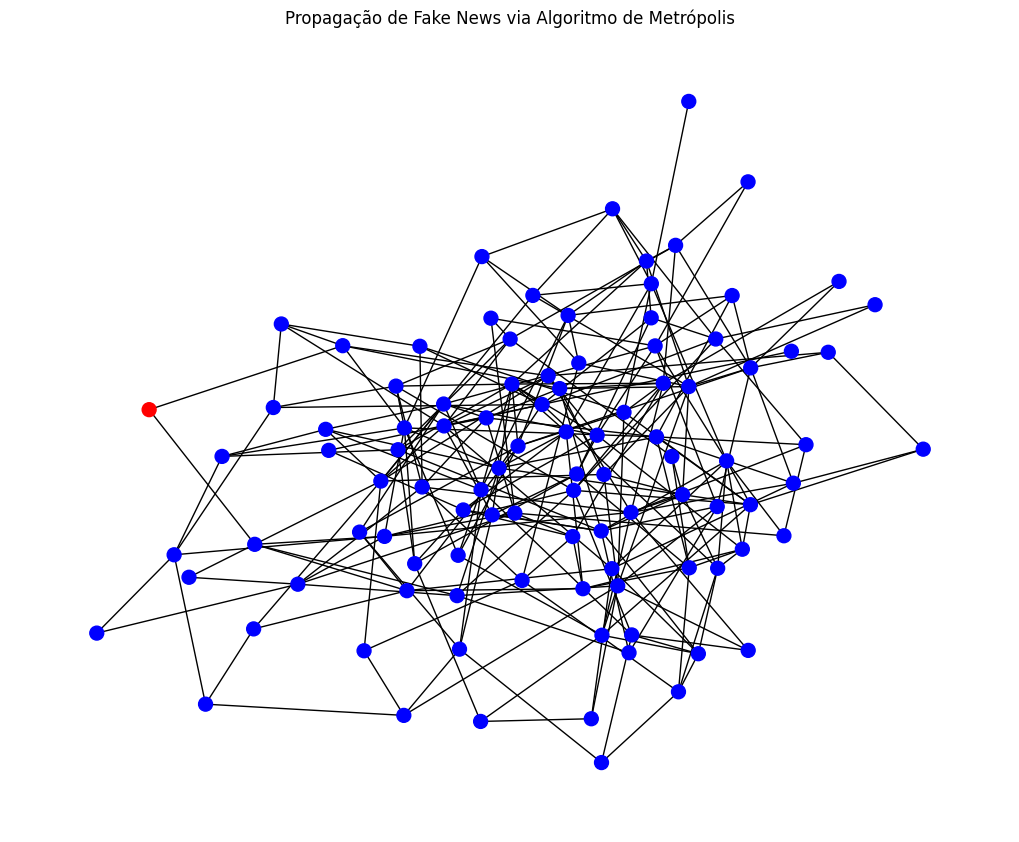

In [94]:
# Visualizar a rede final com cores baseadas na crença
color_map = ['red' if state[no] == 1 else 'blue' for no in G.nodes()]
plt.figure(figsize=(10, 8))
nx.draw(G, node_color=color_map, with_labels=False, node_size=100)
plt.title('Propagação de Fake News via Algoritmo de Metrópolis')
plt.show()

🔍 **Interpretação dos Gráficos:** O algoritmo simula como os usuários mudam de opinião com base na influência dos vizinhos. A tendência pode mostrar estabilização, crescimento ou redução da crença, dependendo da configuração inicial e da estrutura da rede.

### Teste 2: população com líderes crentes

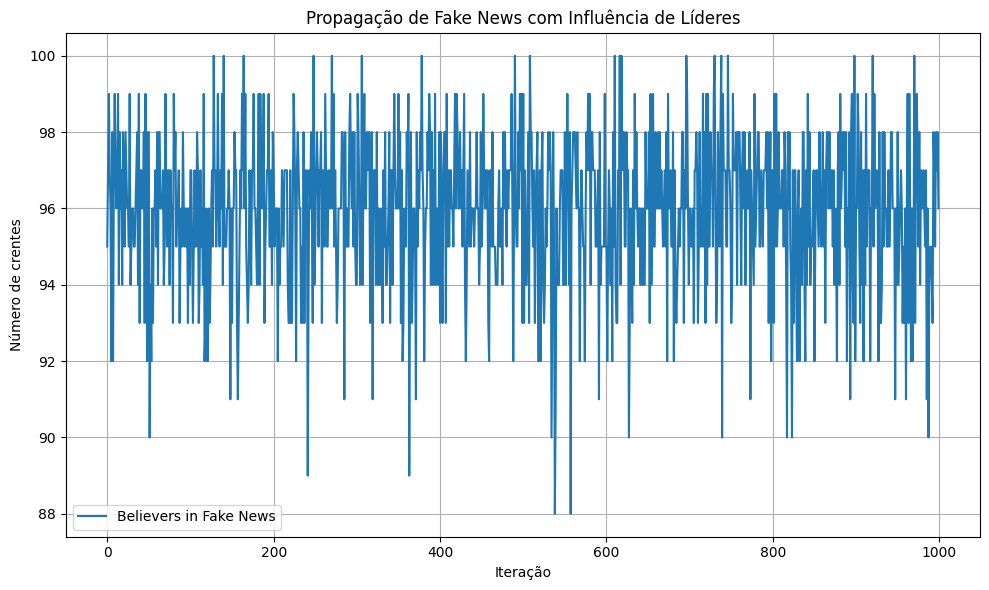

In [151]:
beliefs_over_time = []

# Criar um grafo aleatório 
G = nx.erdos_renyi_graph(num_users, 0.05)

# Atribui os nós líderes (com maior grau e crença fixa em fake news)
leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
leader_nodes = [node for node, _ in leaders]

# Estado inicial: 0 = não acredita, 1 = acredita
beliefs = {node: 1 if node in leader_nodes else random.choice([0, 1]) for node in G.nodes}

# Função de energia: usuários tendem a imitar seus vizinhos
def energy(node, belief):
    neighbors = list(G.neighbors(node))
    if not neighbors:
        return 0
    disagreement = sum(1 for n in neighbors if beliefs[n] != belief)
    return disagreement

# Algoritmo de Metrópolis
for _ in range(iterations):
    for node in G.nodes:
        if node in leader_nodes:
            continue  # líderes não mudam de crença
        current_belief = beliefs[node]
        proposed_belief = 1 - current_belief
        delta_E = energy(node, proposed_belief) - energy(node, current_belief)
        if delta_E <= 0 or random.random() < np.exp(-delta_E):
            beliefs[node] = proposed_belief
    # Registrar número de usuários que acreditam na fake news
    believers = sum(beliefs.values())
    beliefs_over_time.append(believers)

# Visualizar evolução da crença ao longo do tempo
plt.figure(figsize=(10, 6))
plt.plot(beliefs_over_time, label='Believers in Fake News')
plt.xlabel('Iteração')
plt.ylabel('Número de crentes')
plt.title('Propagação de Fake News com Influência de Líderes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

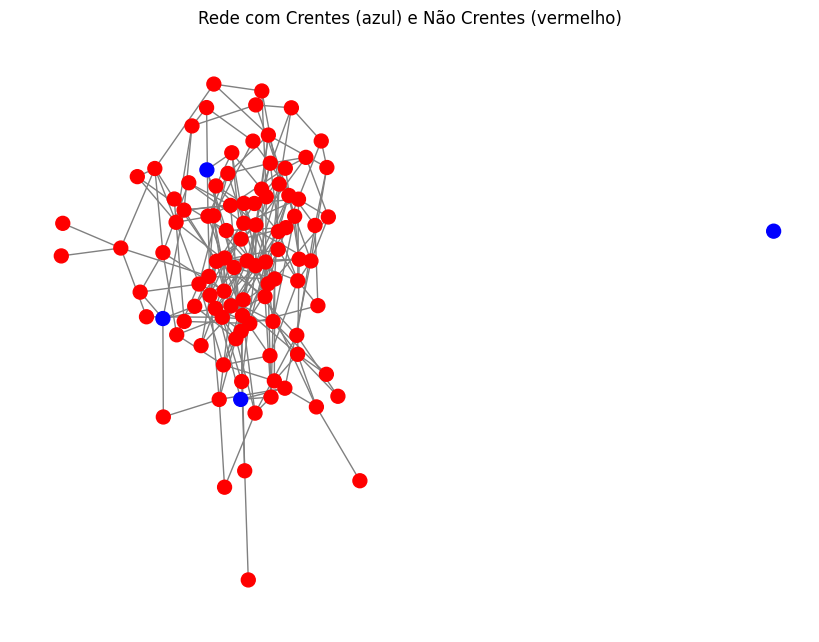

In [152]:
# Visualização da rede com cores baseadas na crença final
cores = ['red' if beliefs[no] == 1 else 'blue' for no in G.nodes]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=cores, with_labels=False, node_size=100, edge_color='gray')
plt.title("Rede com Crentes (azul) e Não Crentes (vermelho)")
plt.show()

🔍 **Interpretação dos Gráficos:** A presença de líderes estabiliza ou acelera a propagação da fake news.
Mesmo que alguns usuários resistam inicialmente, a influência dos líderes tende a aumentar o número de crentes ao longo do tempo. O sistema pode atingir um equilíbrio onde a maioria acredita, dependendo da estrutura da rede.

### Teste 3: população com líderes céticos

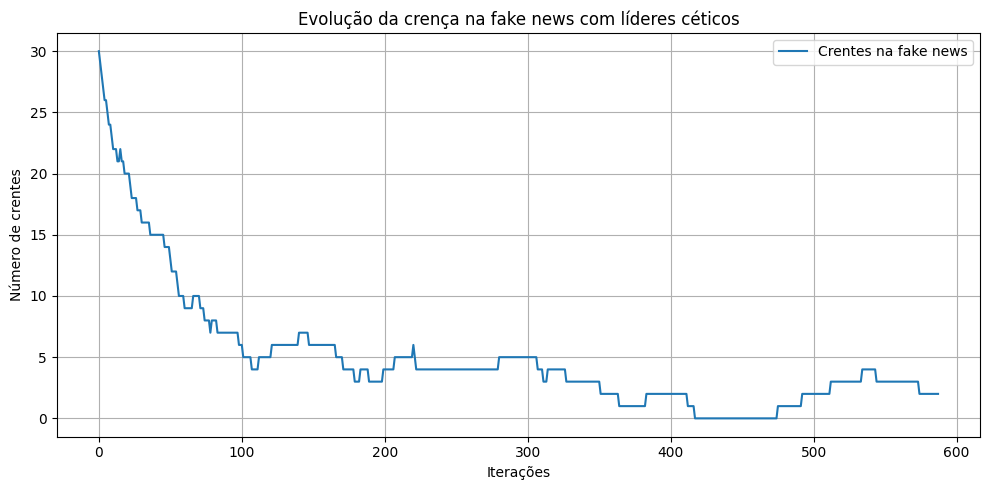

In [144]:
# Criar uma rede aleatória
G = nx.erdos_renyi_graph(num_users, 0.05)

# Atribui os nós líderes (com maior grau e crença fixa em fake news)
belief_state = {node: random.choice([0, 1]) for node in G.nodes}

# Identify leaders (most connected nodes)
degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)
leaders = [node for node, _ in degree_sorted[:num_leaders]]

# Líderes são céticos (não acreditam nas fake news
for leader in leaders:
    belief_state[leader] = 0

# Função de energia: usuários tendem a imitar seus vizinhos
def energy(node, state):
    return sum(state[node] != state[neighbor] for neighbor in G.neighbors(node))

# Algoritmo de Metrópolis
belief_counts = []

for _ in range(iterations):
    node = random.choice(list(G.nodes))
    if node in leaders:
        continue  # líderes não mudam crença

    current_energy = energy(node, belief_state)
    proposed_state = belief_state.copy()
    proposed_state[node] = 1 - proposed_state[node]  # trocam crença
    proposed_energy = energy(node, proposed_state)

    delta_E = proposed_energy - current_energy
    if delta_E <= 0 or random.random() < np.exp(-delta_E):
        belief_state[node] = proposed_state[node]

    # Contar crentes
    believers = sum(belief_state[n] for n in G.nodes)
    belief_counts.append(believers)

# Visualizar a evolução do número de crentes ao longo do tempo
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, label='Crentes na fake news')
plt.xlabel('Iterações')
plt.ylabel('Número de crentes')
plt.title('Evolução da crença na fake news com líderes céticos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

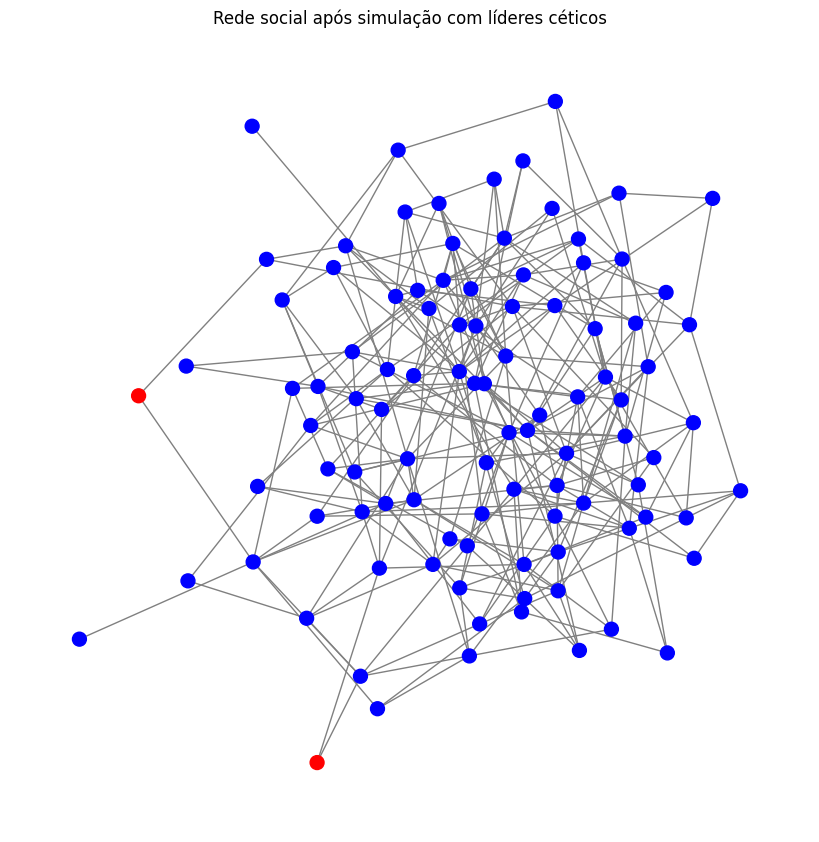

In [145]:
# Visualizar a rede com estados finais
node_colors = []
for node in G.nodes:
    node_colors.append('red' if belief_state[node] == 1 else 'blue')

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=node_colors, with_labels=False, node_size=100, edge_color='gray')
plt.title("Rede social após simulação com líderes céticos")
plt.show()

🔍 **Interpretação dos Gráficos:** A presença de líderes céticos reduz ou estabiliza a propagação da fake news.
Mesmo que alguns usuários acreditem inicialmente, a influência dos líderes tende a conter o crescimento da crença.
O sistema pode atingir um equilíbrio com menos crentes do que no caso com líderes propagadores.

### Teste 4: população com líderes mistos (crentes e céticos)

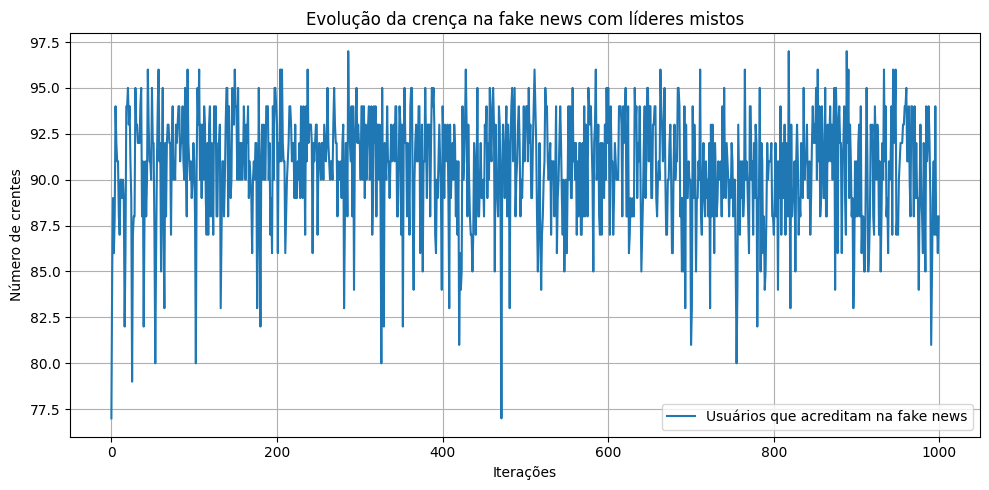

In [101]:
# Criar rede social aleatória
G = nx.erdos_renyi_graph(num_users, 0.05)

# Inicializar estados: 0 = não acredita, 1 = acredita
states = {node: random.choice([0, 1]) for node in G.nodes}

# Identificar líderes com maior grau
degrees = sorted(G.degree, key=lambda x: x[1], reverse=True)
leaders = [node for node, _ in degrees[:num_leaders]]
believer_leaders = leaders[:len(leaders)//2]
skeptic_leaders = leaders[len(leaders)//2:]

# Fixar estados dos líderes
for node in believer_leaders:
    states[node] = 1  # crente fixo
for node in skeptic_leaders:
    states[node] = 0  # cético fixo

# Função de energia: número de discordâncias com vizinhos
def energy(node, state):
    return sum(1 for neighbor in G.neighbors(node) if states[neighbor] != state)

# Simulação com algoritmo de Metrópolis
belief_counts = []

for _ in range(num_iterations):
    for node in G.nodes:
        if node in leaders:
            continue  # líderes não mudam de opinião

        current_state = states[node]
        proposed_state = 1 - current_state

        e_current = energy(node, current_state)
        e_proposed = energy(node, proposed_state)

        delta_e = e_proposed - e_current
        if delta_e <= 0 or random.random() < np.exp(-delta_e):
            states[node] = proposed_state

    # Contar número de crentes
    belief_counts.append(sum(states[n] for n in G.nodes))

# Plotar evolução da crença
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, label='Usuários que acreditam na fake news')
plt.xlabel('Iterações')
plt.ylabel('Número de crentes')
plt.title('Evolução da crença na fake news com líderes mistos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

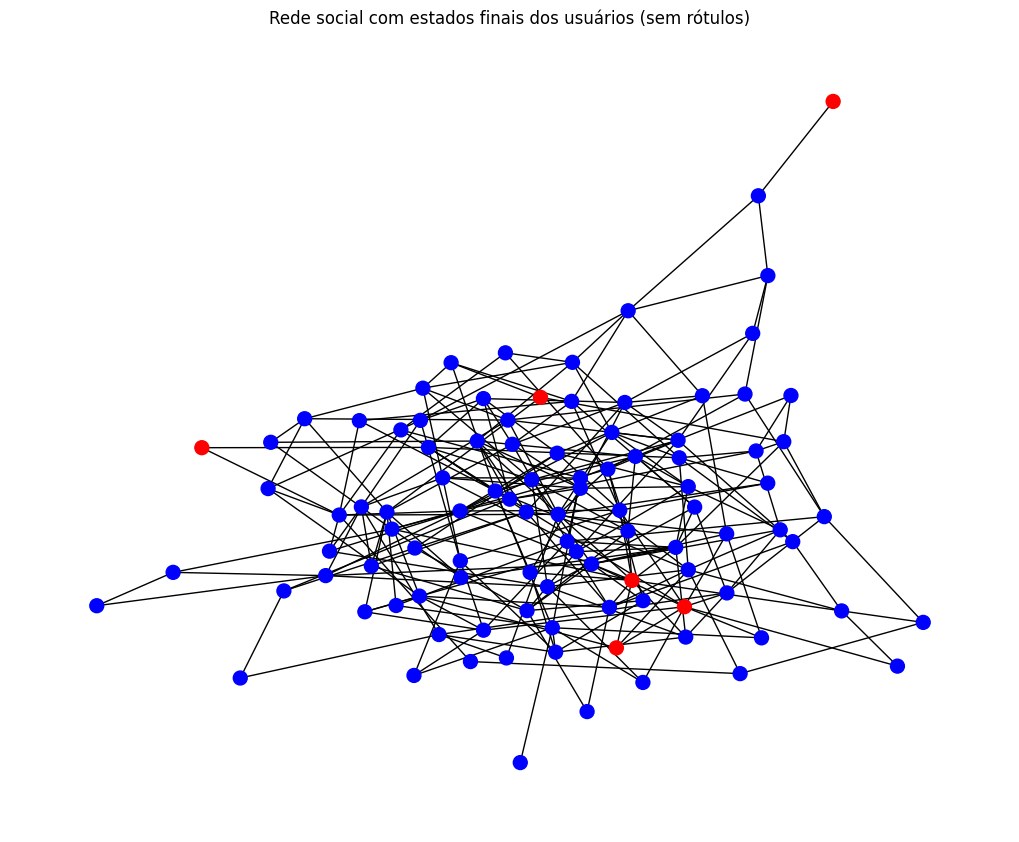

In [102]:
# Criar rede social aleatória
G = nx.erdos_renyi_graph(num_users, 0.05)

# Inicializar estados: 0 = não acredita, 1 = acredita
states = {node: random.choice([0, 1]) for node in G.nodes}

# Identificar líderes com maior grau
degrees = sorted(G.degree, key=lambda x: x[1], reverse=True)
leaders = [node for node, _ in degrees[:num_leaders]]
believer_leaders = leaders[:len(leaders)//2]
skeptic_leaders = leaders[len(leaders)//2:]

# Fixar estados dos líderes
for node in believer_leaders:
    states[node] = 1  # crente fixo
for node in skeptic_leaders:
    states[node] = 0  # cético fixo

# Função de energia: número de discordâncias com vizinhos
def energy(node, state):
    return sum(1 for neighbor in G.neighbors(node) if states[neighbor] != state)

# Simulação com algoritmo de Metrópolis
belief_counts = []

for _ in range(num_iterations):
    for node in G.nodes:
        if node in leaders:
            continue
        current_state = states[node]
        proposed_state = 1 - current_state

        e_current = energy(node, current_state)
        e_proposed = energy(node, proposed_state)

        delta_e = e_proposed - e_current
        if delta_e <= 0 or random.random() < np.exp(-delta_e):
            states[node] = proposed_state

    # Contar número de crentes
    belief_counts.append(sum(states[n] for n in G.nodes))

# Visualizar rede com estados finais (sem números)
colors = ['red' if states[node] == 1 else 'blue' for node in G.nodes]
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_color=colors, with_labels=False, node_size=100)
plt.title('Rede social com estados finais dos usuários (sem rótulos)')
plt.show()

🔍 **Interpretação dos Gráficos:** O comportamento da curva reflete o conflito de influência entre os dois grupos de líderes. A crença na fake news pode oscilar ou estabilizar em um nível intermediário, dependendo da estrutura da rede e da distribuição dos líderes. Esse cenário é mais realista em redes sociais, onde há vozes influentes em ambos os lados.

### E se aplicássemos diferentes temperaturas sociais?

**Regras para o Modelo:**
- Temperatura (T) representa o grau de "agitação social" ou probabilidade de aceitar mudanças contrárias à influência dos vizinhos.
- T = 1: comportamento mais rígido — mudanças só ocorrem se forem vantajosas. A crença cresce lentamente ou estabiliza.
- T = 5: comportamento mais caótico — maior aceitação de mudanças mesmo que não sejam vantajosas. A crença pode oscilar mais ou crescer rapidamente.
- Temperaturas intermediárias mostram um equilíbrio entre conformismo e aleatoriedade.

#### Definindo as temperaturas

In [103]:
temperaturas = [1, 2, 3, 4, 5]

### Teste 5: população com líderes crentes e temperaturas sociais diferentes

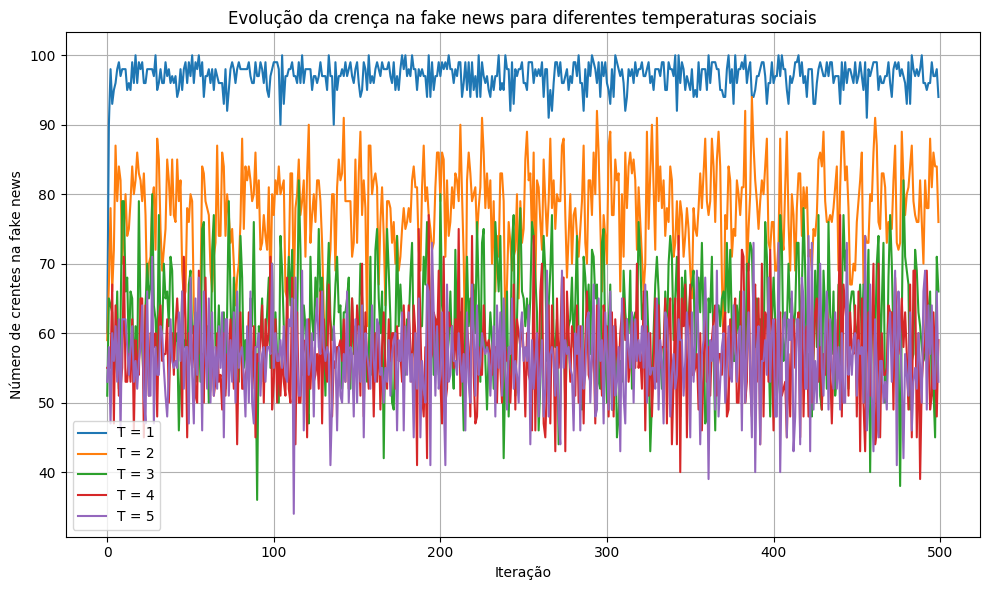

In [105]:
resultados = {}

# Função de simulação com temperatura
def simular_propagacao(T):
    G = nx.erdos_renyi_graph(num_users, 0.05)
    for node in G.nodes():
        G.nodes[node]['belief'] = random.choice([0, 1])
        G.nodes[node]['leader'] = False
        G.nodes[node]['fixed'] = False

    # Selecionar líderes crentes
    leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
    for node, _ in leaders:
        G.nodes[node]['leader'] = True
        G.nodes[node]['fixed'] = True
        G.nodes[node]['belief'] = 1

    crentes_por_iteracao = []

    def metropolis_step(G, T):
        for node in G.nodes():
            if G.nodes[node]['fixed']:
                continue
            current = G.nodes[node]['belief']
            proposed = 1 - current
            neighbors = list(G.neighbors(node))
            influence_current = sum(G.nodes[n]['belief'] == current for n in neighbors)
            influence_proposed = sum(G.nodes[n]['belief'] == proposed for n in neighbors)
            delta_E = influence_current - influence_proposed
            if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
                G.nodes[node]['belief'] = proposed

    for _ in range(iterations):
        metropolis_step(G, T)
        crentes = sum(G.nodes[n]['belief'] == 1 for n in G.nodes())
        crentes_por_iteracao.append(crentes)

    return crentes_por_iteracao

# Executar simulações para diferentes temperaturas
for T in temperaturas:
    resultados[T] = simular_propagacao(T)

# Plotar os resultados
plt.figure(figsize=(10, 6))
for T in temperaturas:
    plt.plot(resultados[T], label=f"T = {T}")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes na fake news")
plt.title("Evolução da crença na fake news para diferentes temperaturas sociais")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("evolucao_crenca_temperaturas.png")
plt.show()

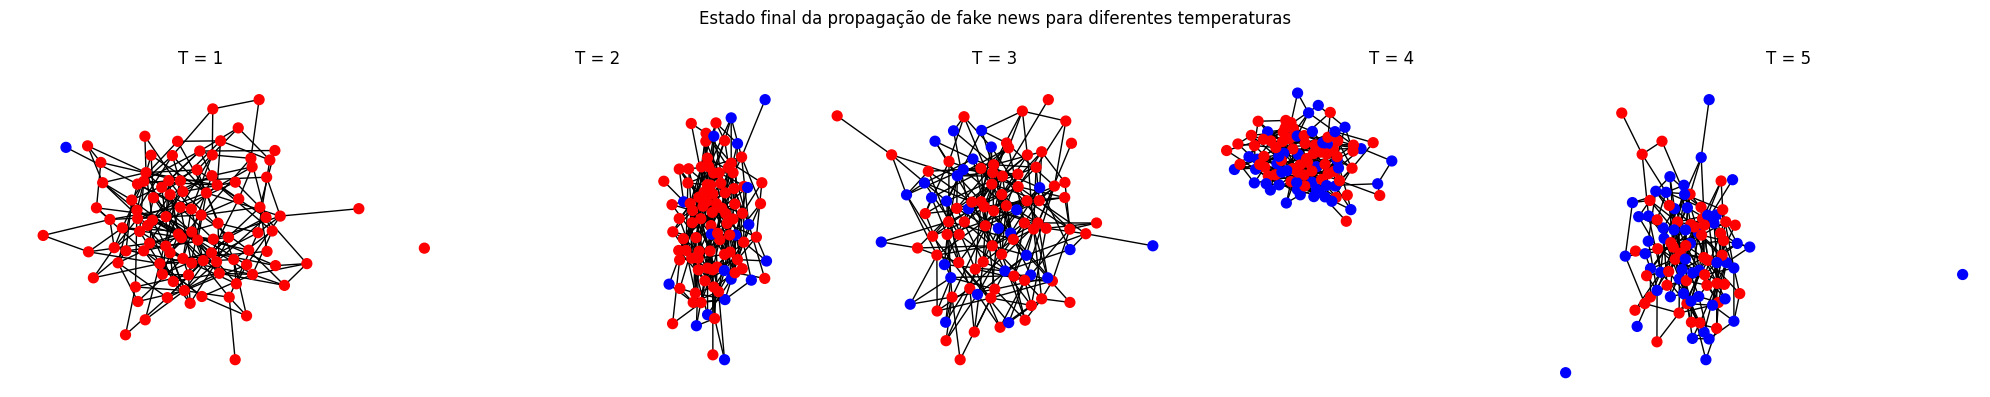

In [122]:
# Função para simular porpagação e retornar grafo final
def simular_propagacao(T):
    G = nx.erdos_renyi_graph(num_users, 0.05)
    for node in G.nodes():
        G.nodes[node]['belief'] = random.choice([0, 1])
        G.nodes[node]['leader'] = False
        G.nodes[node]['fixed'] = False

    # Selecionar líderes
    leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
    for node, _ in leaders:
        G.nodes[node]['leader'] = True
        G.nodes[node]['fixed'] = True
        G.nodes[node]['belief'] = 1

    def metropolis_step(G, T):
        for node in G.nodes():
            if G.nodes[node]['fixed']:
                continue
            current = G.nodes[node]['belief']
            proposed = 1 - current
            neighbors = list(G.neighbors(node))
            influence_current = sum(G.nodes[n]['belief'] == current for n in neighbors)
            influence_proposed = sum(G.nodes[n]['belief'] == proposed for n in neighbors)
            delta_E = influence_current - influence_proposed
            if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
                G.nodes[node]['belief'] = proposed

    for _ in range(iterations):
        metropolis_step(G, T)

    return G

# Gerar e plotar os grafos lado a lado
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for ax, T in zip(axes, temperaturas):
    G = simular_propagacao(T)
    color_map = ['red' if G.nodes[n]['belief'] == 1 else 'blue' for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=color_map, with_labels=False, node_size=50, ax=ax)
    ax.set_title(f"T = {T}")
    ax.axis('off')

plt.suptitle("Estado final da propagação de fake news para diferentes temperaturas")
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** A crença tende a crescer rapidamente, especialmente em temperaturas mais baixas. A influência dos líderes crentes é amplificada quando os usuários estão mais propensos a mudar de opinião (alta temperatura).

### Teste 6: população com líderes céticos e temperaturas sociais diferentes

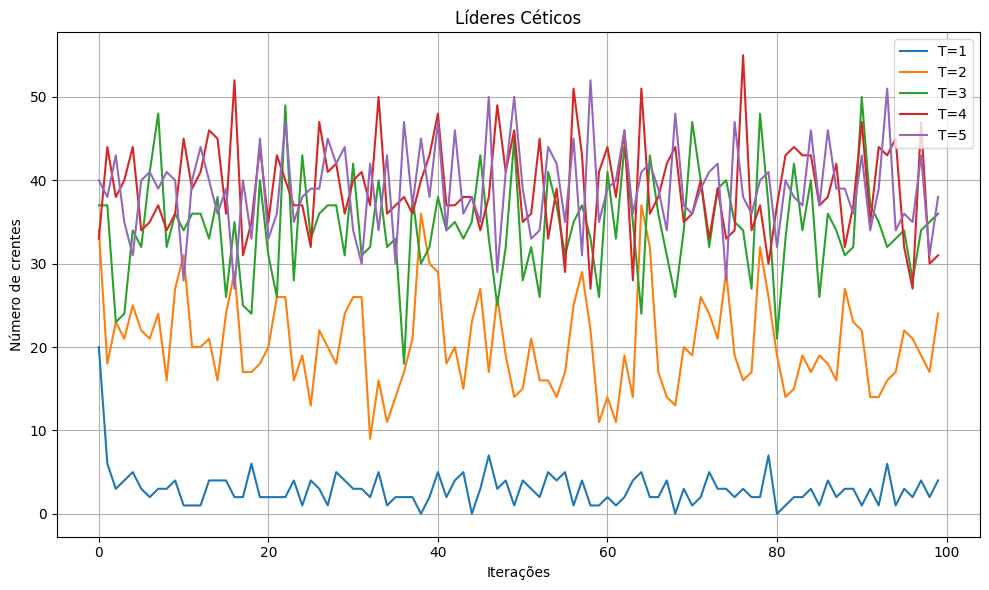

In [107]:
def simulate_fake_news_propagation(temperature, leaders_belief, num_nodes=100, leader_fraction=0.1, iterations=100):
    num_leaders = int(num_nodes * leader_fraction)
    G = nx.erdos_renyi_graph(num_nodes, 0.05)

    for node in G.nodes():
        G.nodes[node]['belief'] = random.choice([0, 1])
        G.nodes[node]['leader'] = False
        G.nodes[node]['fixed'] = False

    leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
    for node, _ in leaders:
        G.nodes[node]['leader'] = True
        G.nodes[node]['fixed'] = True
        G.nodes[node]['belief'] = leaders_belief

    belief_counts = []

    def metropolis_step(G, T):
        for node in G.nodes():
            if G.nodes[node]['fixed']:
                continue
            current = G.nodes[node]['belief']
            proposed = 1 - current
            neighbors = list(G.neighbors(node))
            influence_current = sum(G.nodes[n]['belief'] == current for n in neighbors)
            influence_proposed = sum(G.nodes[n]['belief'] == proposed for n in neighbors)
            delta_E = influence_current - influence_proposed
            if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
                G.nodes[node]['belief'] = proposed

    for _ in range(iterations):
        metropolis_step(G, temperature)
        belief_counts.append(sum(G.nodes[n]['belief'] for n in G.nodes()))

    return belief_counts

# Temperaturas sociais a serem testadas
temperatures = [1, 2, 3, 4, 5]

# Simulações para líderes céticos
results_skeptics = {}

for T in temperatures:
    results_skeptics[T] = simulate_fake_news_propagation(T, leaders_belief=0)

# Plotar apenas os resultados dos líderes céticos
plt.figure(figsize=(10, 6))

for T in temperatures:
    plt.plot(results_skeptics[T], label=f"T={T}")

plt.title("Líderes Céticos")
plt.xlabel("Iterações")
plt.ylabel("Número de crentes")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("fake_news_skeptics_only.png")
plt.show()

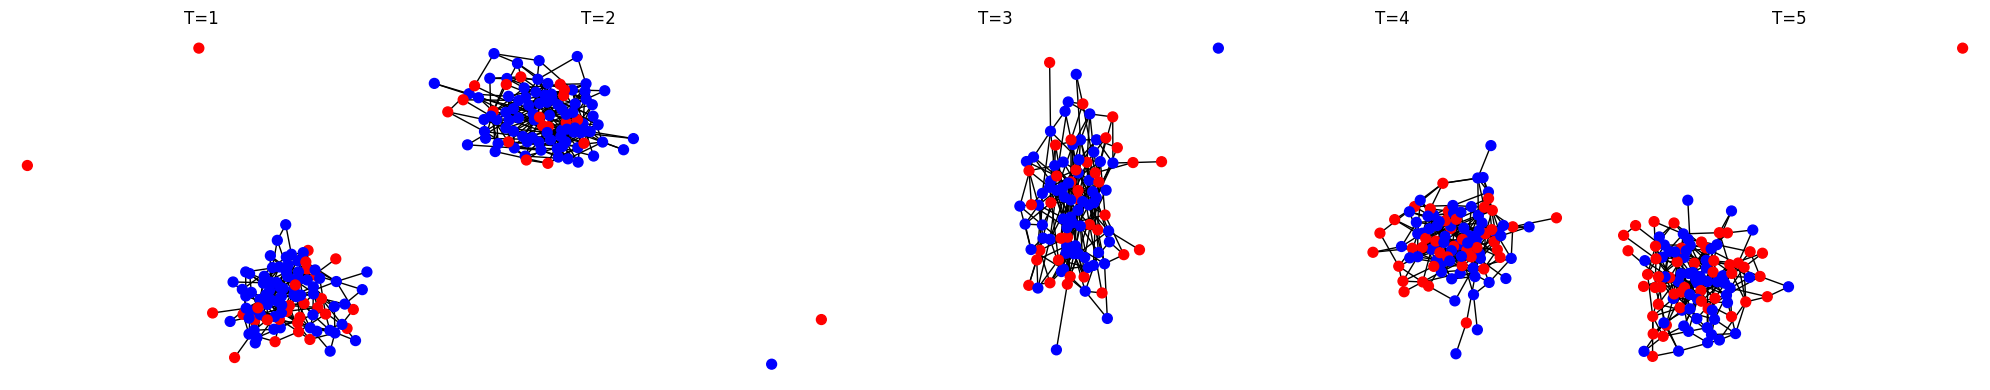

In [108]:
# Função para simular o modelo de Ising com líderes céticos
def ising_simulation_with_skeptic_leaders(temp):
    G = nx.erdos_renyi_graph(num_users, 0.05)
    state = {node: random.choice([0, 1]) for node in G.nodes()}
    num_leaders = int(num_users * leader_fraction)
    
    # Selecionar líderes com maior grau
    leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
    for node, _ in leaders:
        state[node] = 0  # líderes céticos
        G.nodes[node]['fixed'] = True
    for node in G.nodes():
        if 'fixed' not in G.nodes[node]:
            G.nodes[node]['fixed'] = False

    # Algoritmo de Metrópolis
    for _ in range(iterations):
        node = random.choice(list(G.nodes()))
        if G.nodes[node]['fixed']:
            continue
        current = state[node]
        proposed = 1 - current
        delta_E = 0
        for neighbor in G.neighbors(node):
            delta_E += (2 * current - 1) * (2 * state[neighbor] - 1)
        if delta_E <= 0 or random.random() < np.exp(-delta_E / temp):
            state[node] = proposed

    return G, state

# Gerar visualizações lado a lado
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for i, T in enumerate(temperaturas):
    G, final_state = ising_simulation_with_skeptic_leaders(T)
    color_map = ['red' if final_state[node] == 1 else 'blue' for node in G.nodes()]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), node_color=color_map, 
                     with_labels=False, node_size=50, ax=axes[i])
    axes[i].set_title(f"T={T}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("rede_lideres_ceticos_temperaturas_metropolis.png")
plt.show()

🔍 **Interpretação dos Gráficos:** A crença é contida ou até reduzida, principalmente em temperaturas baixas.
Em temperaturas mais altas, há mais flutuação, mas a presença dos líderes céticos ainda exerce um efeito estabilizador.

### Teste 7: população com líderes mistos (crentes e céticos) e temperaturas sociais diferentes

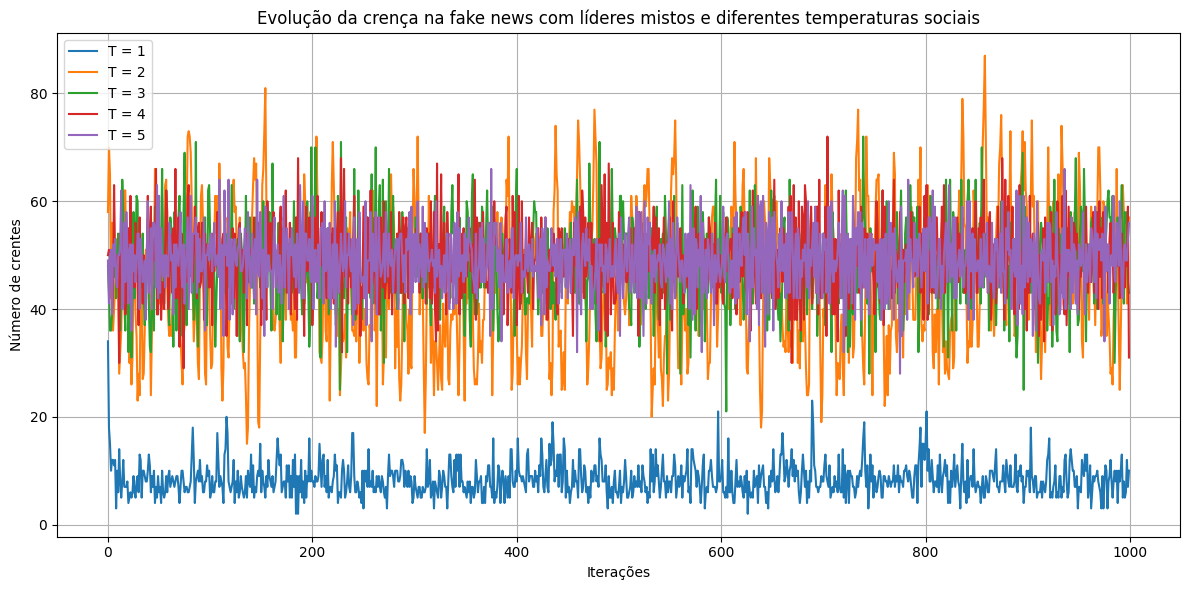

In [110]:
# Criar rede social aleatória
G = nx.erdos_renyi_graph(num_users, 0.05)

# Identificar líderes com maior grau
degrees = sorted(G.degree, key=lambda x: x[1], reverse=True)
leaders = [node for node, _ in degrees[:num_leaders]]
believer_leaders = leaders[:len(leaders)//2]
skeptic_leaders = leaders[len(leaders)//2:]

# Função de energia: número de discordâncias com vizinhos
def energy(node, state, states):
    return sum(1 for neighbor in G.neighbors(node) if states[neighbor] != state)

# Simulação para diferentes temperaturas
plt.figure(figsize=(12, 6))

for T in temperaturas:
    # Inicializar estados aleatórios
    states = {node: random.choice([0, 1]) for node in G.nodes}

    # Fixar estados dos líderes
    for node in believer_leaders:
        states[node] = 1
    for node in skeptic_leaders:
        states[node] = 0

    belief_counts = []

    for _ in range(num_iterations):
        for node in G.nodes:
            if node in leaders:
                continue
            current_state = states[node]
            proposed_state = 1 - current_state

            e_current = energy(node, current_state, states)
            e_proposed = energy(node, proposed_state, states)

            delta_e = e_proposed - e_current
            if delta_e <= 0 or random.random() < np.exp(-delta_e / T):
                states[node] = proposed_state

        belief_counts.append(sum(states[n] for n in G.nodes))

    plt.plot(belief_counts, label=f'T = {T}')

# Plotar gráfico comparativo
plt.xlabel('Iterações')
plt.ylabel('Número de crentes')
plt.title('Evolução da crença na fake news com líderes mistos e diferentes temperaturas sociais')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

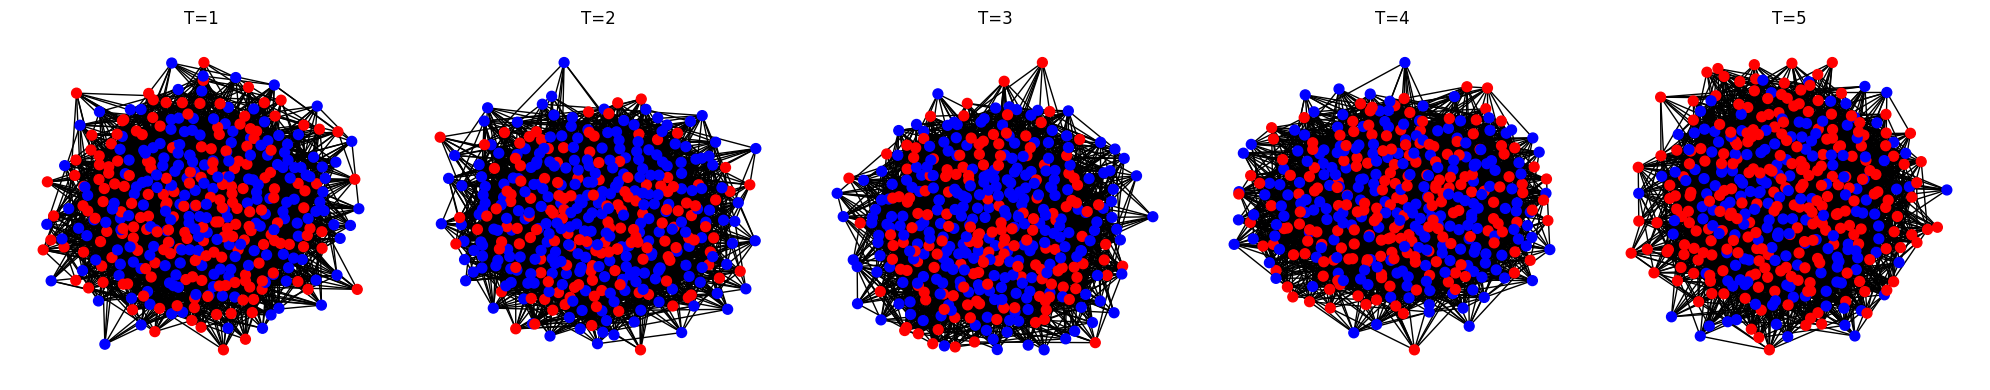

In [111]:
# Função para simular com líderes mistos
def simulation_with_mixed_leaders(temp):
    G = nx.erdos_renyi_graph(num_nodes, 0.05)
    state = {node: random.choice([0, 1]) for node in G.nodes()}
    num_leaders = int(num_nodes * leader_fraction)
    
    # Selecionar líderes com maior grau
    leaders = sorted(G.degree, key=lambda x: x[1], reverse=True)[:num_leaders]
    half = len(leaders) // 2
    for i, (node, _) in enumerate(leaders):
        state[node] = 0 if i < half else 1  # metade céticos, metade crentes
        G.nodes[node]['fixed'] = True
    for node in G.nodes():
        if 'fixed' not in G.nodes[node]:
            G.nodes[node]['fixed'] = False

    # Algoritmo de Metrópolis
    for _ in range(iterations):
        node = random.choice(list(G.nodes()))
        if G.nodes[node]['fixed']:
            continue
        current = state[node]
        proposed = 1 - current
        delta_E = 0
        for neighbor in G.neighbors(node):
            delta_E += (2 * current - 1) * (2 * state[neighbor] - 1)
        if delta_E <= 0 or random.random() < np.exp(-delta_E / temp):
            state[node] = proposed

    return G, state

# Gerar visualizações lado a lado
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))
for i, T in enumerate(temperatures):
    G, final_state = ising_simulation_with_mixed_leaders(T)
    color_map = ['red' if final_state[node] == 1 else 'blue' for node in G.nodes()]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), node_color=color_map, 
                     with_labels=False, node_size=50, ax=axes[i])
    axes[i].set_title(f"T={T}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("rede_lideres_mistos_temperaturas.png")
plt.show()

🔍 **Interpretação dos Gráficos:** Como os líderes têm crenças variadas (alguns acreditam, outros não), eles introduzem diversidade de opinião na rede.
Isso dificulta a convergência total para uma única crença, especialmente em temperaturas médias e altas.

### Teste 8: situação de consenso

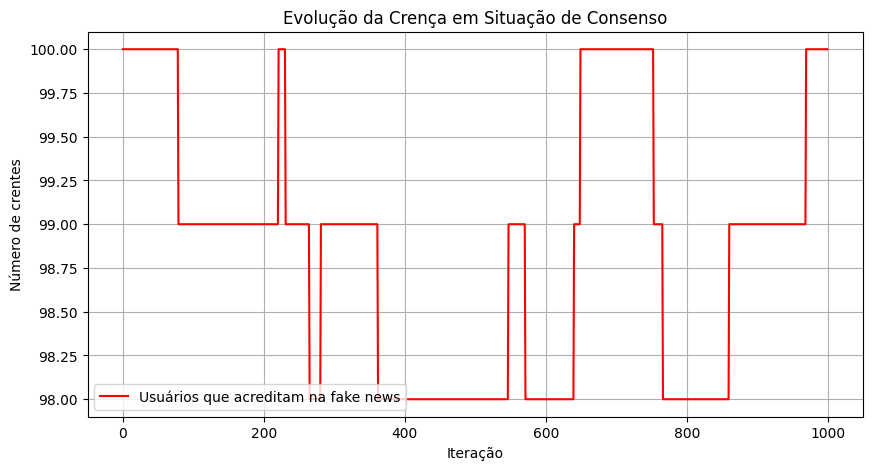

In [112]:
# Parâmetros da simulação
numero_pessoas = 100
numero_iteracoes = 1000
temperatura = 0.1  # Temperatura baixa para favorecer o consenso

# Criar uma rede social aleatória
G = nx.erdos_renyi_graph(n=numero_pessoas, p=0.05)

# Estado inicial: todos acreditam (consenso)
state = {node: 1 for node in G.nodes()}

# Função de energia: usuários tendem a imitar seus vizinhos
def energia(state, G):
    E = 0
    for no in G.nodes():
        for vizinho in G.neighbors(no):
            if state[no] != state[vizinho]:
                E += 1  # penalidade por discordância
    return E

# Algoritmo de Metrópolis
belief_counts = []
for _ in range(numero_iteracoes):
    no = random.choice(list(G.nodes()))
    novo_estado = state.copy()
    novo_estado[no] = 1 - novo_estado[no]  # inverte crença

    E_atual = energia(state, G)
    E_novo = energia(novo_estado, G)

    delta_E = E_novo - E_atual
    if delta_E < 0 or random.random() < np.exp(-delta_E / temperatura):
        state = novo_estado

    belief_counts.append(sum(state.values()))

# Visualizar evolução da crença ao longo do tempo
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, label='Usuários que acreditam na fake news', color='red')
plt.xlabel('Iteração')
plt.ylabel('Número de crentes')
plt.title('Evolução da Crença em Situação de Consenso')
plt.legend()
plt.grid(True)
plt.show()

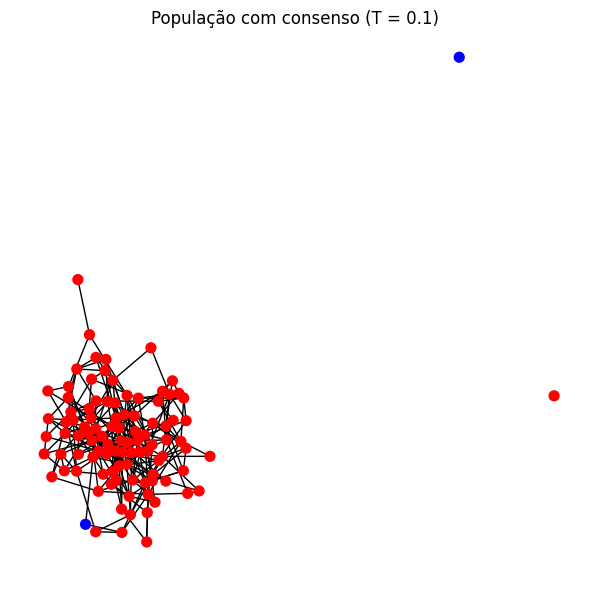

In [113]:
# Algoritmo de Metrópolis sem líderes
for _ in range(iterations):
    node = random.choice(list(G.nodes()))
    current = state[node]
    proposed = 1 - current
    delta_E = 0
    for neighbor in G.neighbors(node):
        delta_E += (2 * current - 1) * (2 * state[neighbor] - 1)
    if delta_E <= 0 or random.random() < np.exp(-delta_E / temperature):
        state[node] = proposed

# Visualização
color_map = ['red' if state[node] == 1 else 'blue' for node in G.nodes()]
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6, 6))
nx.draw_networkx(G, pos=pos, node_color=color_map, with_labels=False, node_size=50)
plt.title("População com consenso (T = 0.1)")
plt.axis('off')
plt.tight_layout()
plt.savefig("ising_sem_lideres_T01.png")
plt.show()

🔍 **Interpretação dos Gráficos:** O número de crentes permanece alto ao longo do tempo, com pequenas flutuações. Isso indica que, mesmo com algumas tentativas de mudança de opinião (por aleatoriedade), o sistema retorna rapidamente ao estado de consenso. A energia do sistema favorece a uniformidade de crença, e a baixa temperatura penaliza mudanças que aumentariam a discordância.

### Teste 9: situação de consenso com temperaturas sociais diferentes

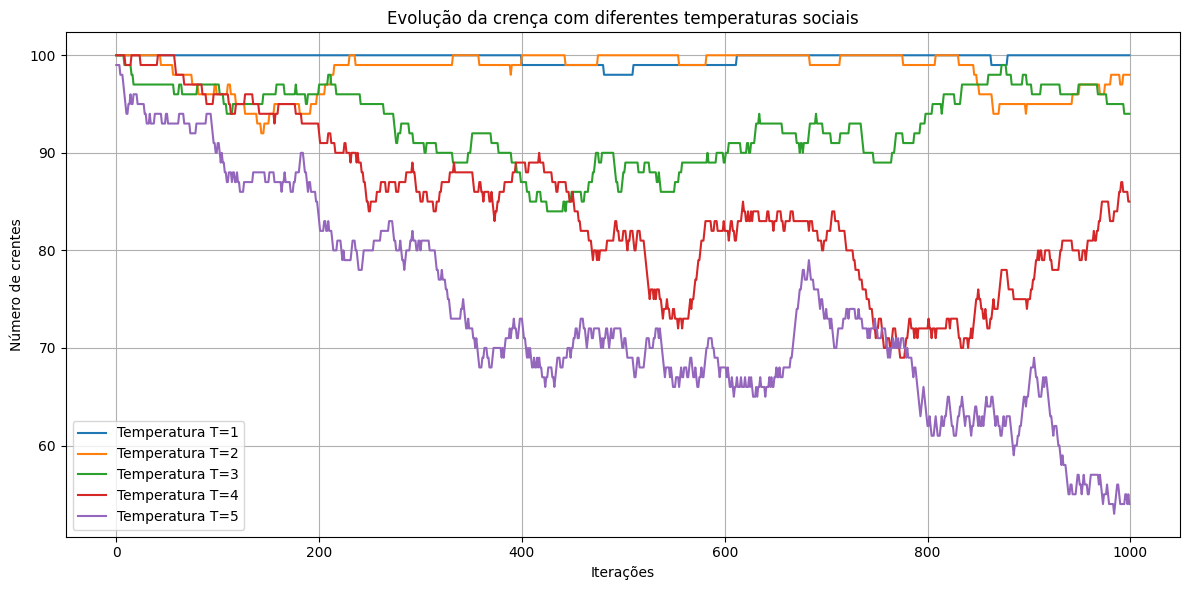

In [114]:
# Parâmetros da simulação
numero_pessoas = 100
numero_iteracoes = 1000

# Criar uma rede social aleatória
G = nx.erdos_renyi_graph(n=numero_pessoas, p=0.05)

# Função de energia: usuários tendem a imitar seus vizinhos
def energy(state, G):
    E = 0
    for no in G.nodes():
        for vizinho in G.neighbors(no):
            if state[no] != state[vizinho]:
                E += 1  # penalidade por discordância
    return E

# Executar simulações para diferentes temperaturas
plt.figure(figsize=(12, 6))
for T in temperaturas:
    # Estado inicial: todos acreditam (consenso)
    state = {node: 1 for node in G.nodes()}
    belief_counts = []

    for _ in range(numero_iteracoes):
        no = random.choice(list(G.nodes()))
        novoEstado = state.copy()
        novoEstado[no] = 1 - novoEstado[no]  # inverte crença

        E_current = energy(state, G)
        E_new = energy(novoEstado, G)

        delta_E = E_new - E_current
        if delta_E < 0 or random.random() < np.exp(-delta_E / T):
            state = novoEstado

        belief_counts.append(sum(state.values()))

    plt.plot(belief_counts, label=f'Temperatura T={T}')

plt.xlabel('Iterações')
plt.ylabel('Número de crentes')
plt.title('Evolução da crença com diferentes temperaturas sociais')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("evolucao_crenca_temperaturas_altas.png")
plt.show()

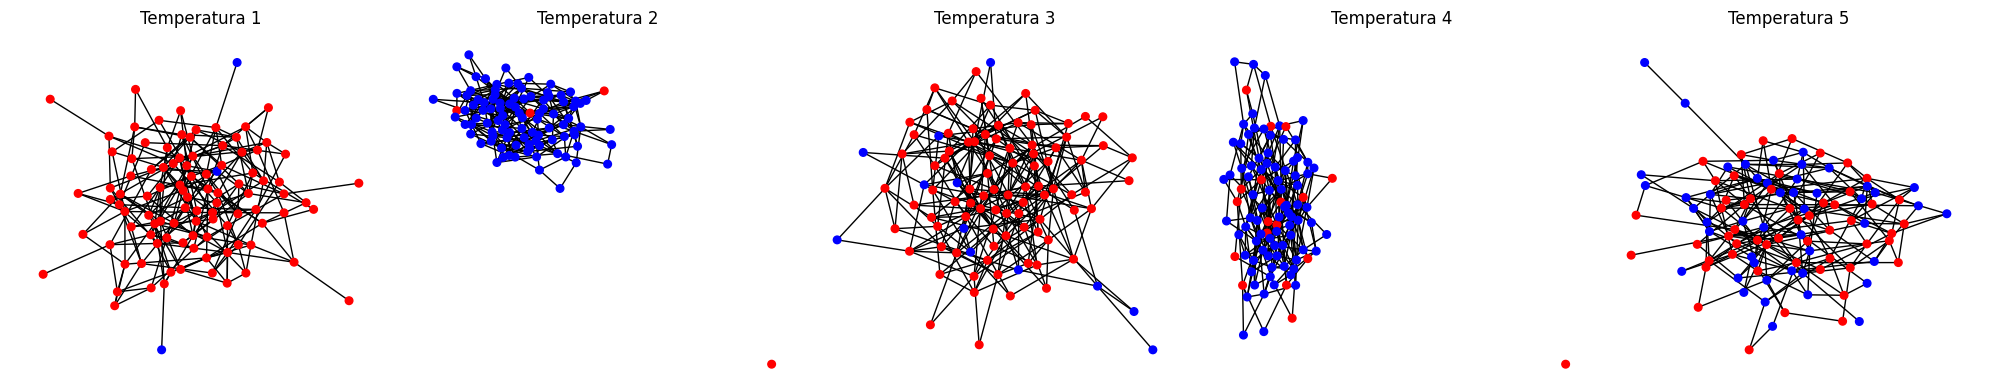

In [115]:
# Parâmetros da simulação
numero_pessoas = 100
numero_iteracoes = 1000

# Função de energia
def energy(state, G):
    E = 0
    for no in G.nodes():
        for vizinho in G.neighbors(no):
            if state[no] != state[vizinho]:
                E += 1
    return E

# Função para simular e retornar o estado final da rede
def simular_rede(temperatura):
    G = nx.erdos_renyi_graph(n=numero_pessoas, p=0.05)
    state = {node: random.choice([0, 1]) for node in G.nodes()}

    for _ in range(numero_iteracoes):
        no = random.choice(list(G.nodes()))
        novoEstado = state.copy()
        novoEstado[no] = 1 - novoEstado[no]
        E_current = energy(state, G)
        E_new = energy(novoEstado, G)
        delta_E = E_new - E_current
        if delta_E < 0 or random.random() < np.exp(-delta_E / temperatura):
            state = novoEstado

    return G, state

# Executar simulações para cada temperatura
redes_finais = []
for T in temperaturas:
    G, state = simular_rede(T)
    redes_finais.append((T, G, state))

# Plotar redes lado a lado
fig, axs = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for i, (T, G, state) in enumerate(redes_finais):
    cores = ['red' if state[n] == 1 else 'blue' for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=cores, ax=axs[i], node_size=30, with_labels=False)
    axs[i].set_title(f'Temperatura {T}')
    axs[i].axis('off')

plt.tight_layout()
plt.savefig("redes_finais_temperaturas.png")
plt.show()

🔍 **Interpretação dos Gráficos:** Temperaturas baixas favorecem a estabilidade e a manutenção de crenças, mesmo que sejam falsas. Temperaturas altas promovem diversidade de opinião, dificultando o consenso e permitindo que crenças sejam mais facilmente questionadas ou abandonadas.

---

## - Método 2: Modelo de Ising

O **modelo de Ising** é um modelo matemático originalmente desenvolvido na física estatística para estudar o **magnetismo em materiais**, mas ele também é amplamente utilizado em outras áreas, como sociologia, economia e ciência de redes — inclusive para entender a **propagação de fake news**.

---

### O que é o Modelo de Ising?

No modelo de Ising:

- Cada **nó** (ou "átomo") em uma rede tem um **estado binário**: geralmente representado como +1 ou -1.
- Esses nós estão conectados a **vizinhos** e tendem a **alinhar seus estados** com os deles, minimizando a "energia" do sistema.
- A **temperatura** controla o grau de aleatoriedade: em temperaturas baixas, os nós seguem mais rigidamente seus vizinhos; em temperaturas altas, há mais liberdade para mudar de estado.

---

### Aplicação do Modelo de Ising para Fake News

Podemos reinterpretar o modelo de Ising no contexto social:

| Física (Ising)         | Sociedade (Fake News)                          |
|------------------------|------------------------------------------------|
| Spin (+1 ou -1)        | Crença (acredita ou não na fake news)         |
| Interação entre spins  | Influência social entre indivíduos            |
| Energia do sistema     | Grau de discordância entre vizinhos           |
| Temperatura            | Abertura à mudança de opinião (ruído social)  |

#### Dinâmica:
- Cada pessoa tende a **imitar a opinião da maioria dos seus vizinhos**.
- A **energia** aumenta quando há **discordância** entre vizinhos.
- A **temperatura social** permite que indivíduos **mudem de opinião mesmo contra a maioria**, simulando fatores como dúvida, exposição a novas fontes ou rebeldia.

---

### O que o modelo ajuda a entender?

1. **Formação de consenso**: Em temperaturas baixas, a sociedade tende a se alinhar em uma única crença — verdadeira ou falsa.
2. **Polarização**: Em certas condições, o modelo pode gerar **clusters de crença oposta**, simulando bolhas de informação.
3. **Resiliência à desinformação**: Pode-se testar como a introdução de "líderes" ou "agentes informados" afeta a propagação da fake news.
4. **Impacto da temperatura**: Mostra como sociedades mais abertas à mudança (alta temperatura) podem resistir melhor à desinformação, mas também podem ser mais instáveis.

---

### Como aplicar o Modelo de Ising para estudar fake news

### 1. Modelagem da Rede
- Cada **nó** representa um usuário.
- Cada **aresta** representa uma conexão social (amizade, seguidores, etc.).
- Cada nó pode estar em um **estado binário**:
  - `1` → acredita na fake news  
  - `0` → não acredita

---

### 2. Definir a Função de Energia (ou Custo)
A **função de energia** $E(x)$ mede o "custo social" de um determinado estado da rede. Ela pode considerar:
- A **discordância entre vizinhos** (usuários tendem a imitar seus contatos).
- A **influência de líderes** ou usuários com muitos seguidores.
- A **homogeneidade local**: quanto mais alinhado um usuário estiver com seus vizinhos, menor a energia.

- Exemplo de função: $E(x) = \sum_{(i,j) \in \text{arestas}} \mathbb{1}[x_i \neq x_j]$
---

### 3. Distribuição Alvo
A distribuição de probabilidade dos estados da rede é dada por: $π(x) \propto e^{-\frac{E(x)}{T}}$
- Estados com **menor energia** (mais coerentes socialmente) são **mais prováveis**.
- A **temperatura \( T \)** controla o nível de aleatoriedade:
  - Temperatura baixa → conformismo
  - Temperatura alta → maior diversidade de opiniões

---

### 4. Aplicação do Algoritmo de Metrópolis
1. Comece com um estado inicial (ex: todos acreditam na fake news).
2. Escolha um usuário aleatoriamente.
3. Proponha uma mudança de estado (inverter a crença).
4. Calcule a nova energia $E_{\text{novo}}$.
5. Aceite a mudança com probabilidade: $min\left(1, e^{-\frac{\Delta E}{T}}\right)$
onde $ΔE = E_{\text{novo}} - E_{\text{atual}}$.

---

### 5. Simulação
Após várias iterações, é possível observar:
- Como a fake news se espalha ou desaparece.
- A influência da temperatura social na estabilidade das crenças
---

## Implementando o Modelo Computacional

## - Rede 20x20

### Teste 1: população sem líderes

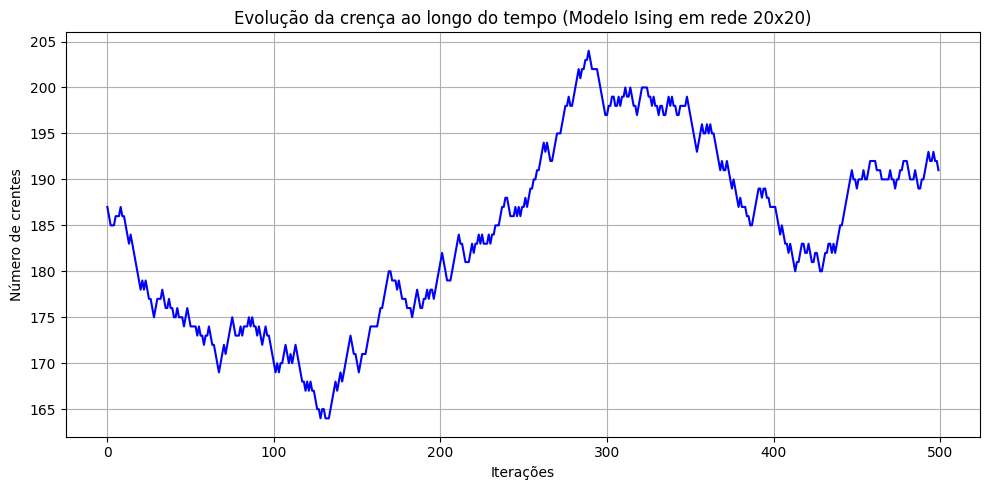

In [123]:
# Parâmetros
grid_size = 20
temperature = 2.0
iterations = 500

# Inicializar rede com estados aleatórios (0 ou 1)
grid = np.random.choice([0, 1], size=(grid_size, grid_size))

# Função para calcular mudança de energia
def delta_energy(grid, x, y):
    current = grid[x, y]
    proposed = 1 - current
    neighbors = [
        grid[(x - 1) % grid_size, y],
        grid[(x + 1) % grid_size, y],
        grid[x, (y - 1) % grid_size],
        grid[x, (y + 1) % grid_size]
    ]
    influence_current = sum(1 if n == current else 0 for n in neighbors)
    influence_proposed = sum(1 if n == proposed else 0 for n in neighbors)
    return influence_current - influence_proposed

# Armazenar o número de crentes ao longo do tempo
belief_counts = []

# Modelo de Ising
for _ in range(iterations):
    x, y = random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)
    dE = delta_energy(grid, x, y)
    if dE <= 0 or random.random() < np.exp(-dE / temperature):
        grid[x, y] = 1 - grid[x, y]
    belief_counts.append(np.sum(grid))

# Visualização
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, color='blue')
plt.xlabel("Iterações")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença ao longo do tempo (Modelo Ising em rede 20x20)")
plt.grid(True)
plt.tight_layout()
plt.show()

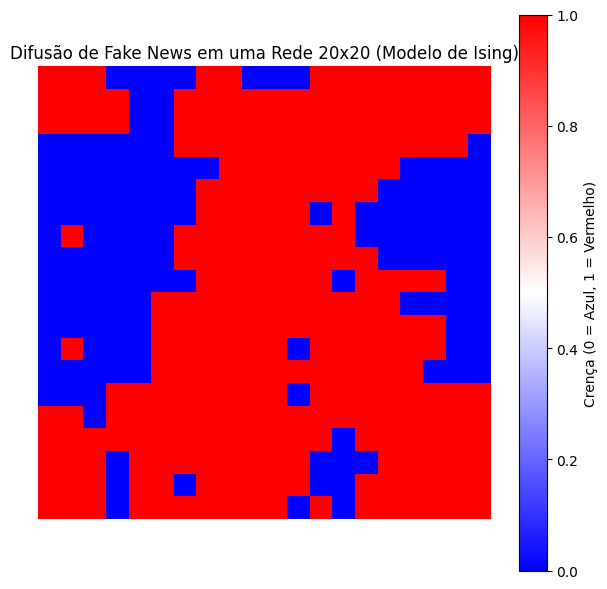

In [125]:
# Parâmetros
grid_size = 20
temperature = 2.0
iterations = 10000

# Inicializar rede com estados aleatórios (0 ou 1)
grid = np.random.choice([0, 1], size=(grid_size, grid_size))

# Converter os nós para valores spin (-1, 1)
spins = 2 * grid - 1

# Definir função para computar mudança de energia
def delta_energy(spins, i, j):
    neighbors = [
        spins[(i - 1) % grid_size, j],
        spins[(i + 1) % grid_size, j],
        spins[i, (j - 1) % grid_size],
        spins[i, (j + 1) % grid_size]
    ]
    return 2 * spins[i, j] * sum(neighbors)

for _ in range(iterations):
    i, j = random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)
    dE = delta_energy(spins, i, j)
    if dE <= 0 or random.random() < np.exp(-dE / temperature):
        spins[i, j] *= -1

# Converter spins para crentes (0 or 1)
final_beliefs = (spins + 1) // 2

# Visualizar o estado final
plt.figure(figsize=(6, 6))
plt.imshow(final_beliefs, cmap='bwr', interpolation='nearest')
plt.title("Difusão de Fake News em uma Rede 20x20 (Modelo de Ising)")
plt.colorbar(label='Crença (0 = Azul, 1 = Vermelho)')
plt.axis('off')
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** O número de crentes oscila ao longo do tempo, sem convergir rapidamente para um consenso. Isso indica que a sociedade está em um estado dinâmico, onde a crença na fake news não se estabiliza facilmente. A temperatura intermediária permite que pequenos grupos de opinião contrária persistam, criando um equilíbrio instável.

### Teste 2: população com líderes crentes

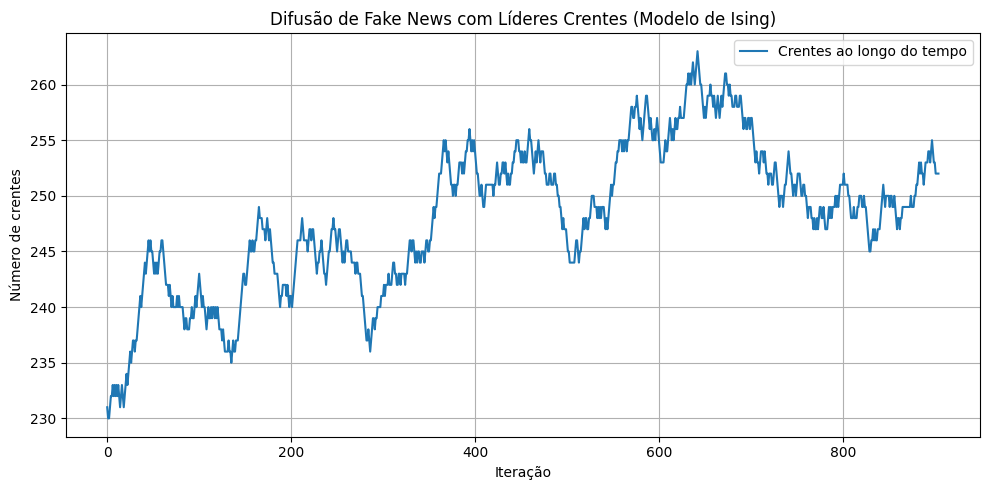

In [153]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
temperature = 2.0
iterations = 1000

# Criar uma rede 2D
G = nx.grid_2d_graph(grid_size, grid_size)
mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, mapping)

# Inicializar estados aleatoriamente
state = {node: random.choice([0, 1]) for node in G.nodes()}

# Selecionar líderes
num_leaders = int(num_nodes * leader_fraction)
leaders = random.sample(list(G.nodes()), num_leaders)
for node in G.nodes():
    G.nodes[node]['fixed'] = node in leaders
    if G.nodes[node]['fixed']:
        state[node] = 1  # líderes crentes

belief_counts = []

for _ in range(iterations):
    node = random.choice(list(G.nodes()))
    if G.nodes[node]['fixed']:
        continue
    current = state[node]
    proposed = 1 - current
    delta_E = 0
    for neighbor in G.neighbors(node):
        delta_E += (2 * current - 1) * (2 * state[neighbor] - 1)
    if delta_E <= 0 or random.random() < np.exp(-delta_E / temperature):
        state[node] = proposed
    belief_counts.append(sum(state.values()))

# Visualização
plt.figure(figsize=(10, 5))
plt.plot(belief_counts, label='Crentes ao longo do tempo')
plt.xlabel('Iteração')
plt.ylabel('Número de crentes')
plt.title('Difusão de Fake News com Líderes Crentes (Modelo de Ising)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

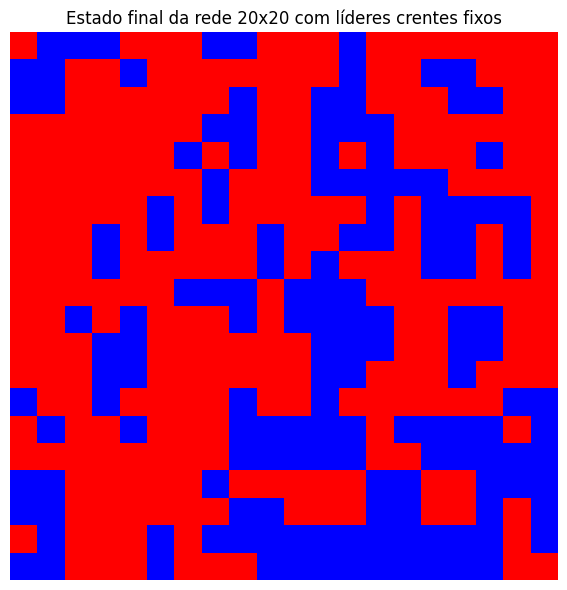

In [154]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
temperature = 2.0
iterations = 1000

# Inicializar rede com estados aleatórios (0 ou 1)
state = np.random.choice([0, 1], size=(grid_size, grid_size))

# Selecionar líderes crentes fixos
num_leaders = int(num_nodes * leader_fraction)
leader_indices = random.sample(range(num_nodes), num_leaders)
leader_positions = [(idx // grid_size, idx % grid_size) for idx in leader_indices]

# Marcar líderes como crentes fixos
fixed = np.zeros((grid_size, grid_size), dtype=bool)
for i, j in leader_positions:
    state[i, j] = 1
    fixed[i, j] = True

# Define vizinhos
def get_neighbors(i, j):
    neighbors = []
    if i > 0: neighbors.append((i-1, j))
    if i < grid_size - 1: neighbors.append((i+1, j))
    if j > 0: neighbors.append((i, j-1))
    if j < grid_size - 1: neighbors.append((i, j+1))
    return neighbors

for _ in range(iterations):
    i, j = random.randint(0, grid_size-1), random.randint(0, grid_size-1)
    if fixed[i, j]:
        continue
    current = state[i, j]
    proposed = 1 - current
    neighbors = get_neighbors(i, j)
    influence_current = sum(state[ni, nj] == current for ni, nj in neighbors)
    influence_proposed = sum(state[ni, nj] == proposed for ni, nj in neighbors)
    delta_E = influence_current - influence_proposed
    if delta_E <= 0 or random.random() < np.exp(-delta_E / temperature):
        state[i, j] = proposed

# Visualização do estado final
plt.figure(figsize=(6, 6))
plt.imshow(state, cmap='bwr', interpolation='nearest')
plt.title("Estado final da rede 20x20 com líderes crentes fixos")
plt.axis('off')
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** O número de crentes aumenta gradualmente ao longo das iterações. A presença de líderes fixos puxa a rede em direção ao consenso positivo (acreditar na fake news). Mesmo com temperatura 2.0 (que permite flutuações), os líderes exercem influência estabilizadora.

### Teste 3: população com líderes céticos

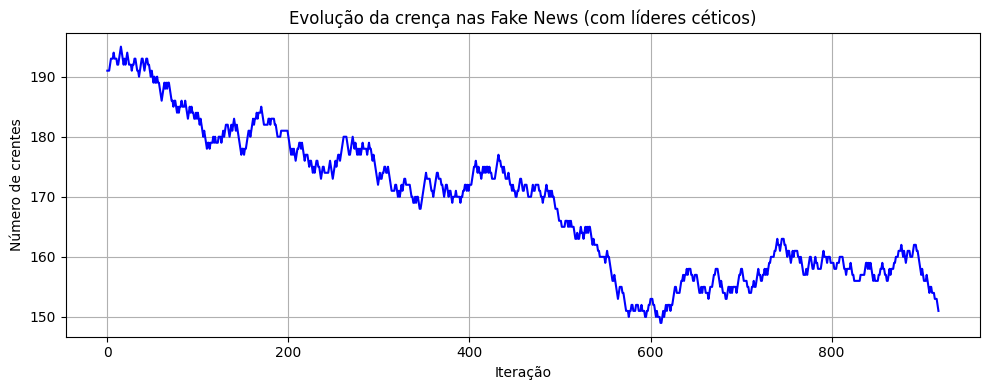

In [155]:
# Parâmetros
grid_size = 20
temperature = 2.0
iterations = 1000
leader_fraction = 0.1

# Inicializar rede com estados aleatórios (0 ou 1)
state = np.random.choice([0, 1], size=(grid_size, grid_size))

# Selecionar líderes céticos fixos
num_leaders = int(grid_size * grid_size * leader_fraction)
leader_indices = np.random.choice(grid_size * grid_size, num_leaders, replace=False)
fixed_mask = np.zeros((grid_size, grid_size), dtype=bool)
for idx in leader_indices:
    i, j = divmod(idx, grid_size)
    state[i, j] = 0  # cético
    fixed_mask[i, j] = True

# Função para diferença de energia
def delta_energy(state, i, j, proposed):
    current = state[i, j]
    neighbors = []
    if i > 0: neighbors.append(state[i-1, j])
    if i < grid_size - 1: neighbors.append(state[i+1, j])
    if j > 0: neighbors.append(state[i, j-1])
    if j < grid_size - 1: neighbors.append(state[i, j+1])
    influence_current = sum(1 if n == current else 0 for n in neighbors)
    influence_proposed = sum(1 if n == proposed else 0 for n in neighbors)
    return influence_current - influence_proposed

# Simulação
belief_counts = []
for _ in range(iterations):
    i, j = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
    if fixed_mask[i, j]:
        continue
    proposed = 1 - state[i, j]
    dE = delta_energy(state, i, j, proposed)
    if dE <= 0 or np.random.rand() < np.exp(-dE / temperature):
        state[i, j] = proposed
    belief_counts.append(np.sum(state))

# Visualização
plt.figure(figsize=(10, 4))
plt.plot(belief_counts, color='blue')
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença nas Fake News (com líderes céticos)")
plt.grid(True)
plt.tight_layout()
plt.show()

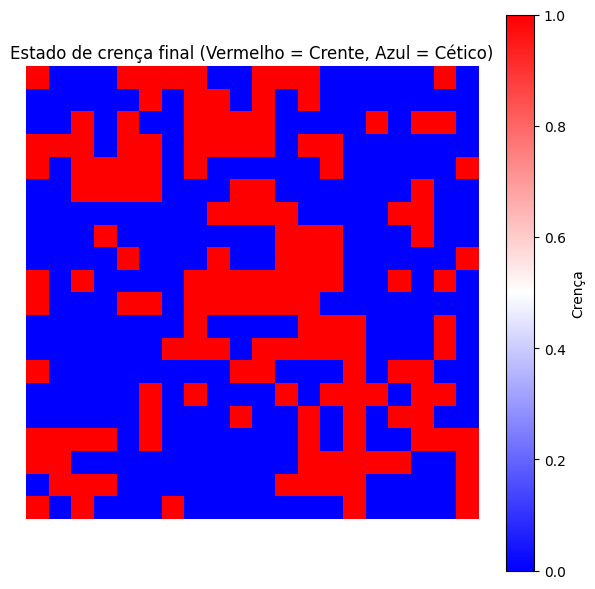

In [156]:
# Visualização do mapa
plt.figure(figsize=(6, 6))
plt.imshow(state, cmap='bwr', interpolation='nearest')
plt.title("Estado de crença final (Vermelho = Crente, Azul = Cético)")
plt.colorbar(label='Crença')
plt.axis('off')
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** A presença de líderes céticos desacelera a propagação da fake news. Isso mostra como atores influentes com opiniões críticas podem ajudar a conter a desinformação, mesmo em ambientes sociais dinâmicos.

### Teste 4: população com líderes mistos (crentes e céticos)

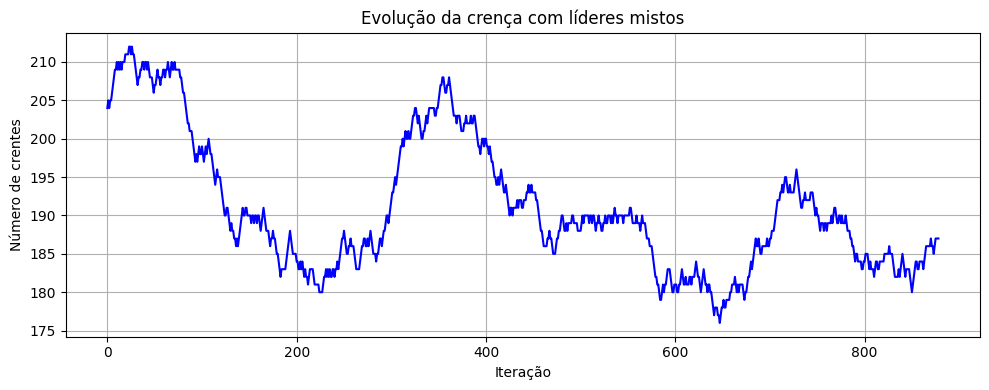

In [130]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
temperature = 2.0
iterations = 1000

# Inicializar rede com estados aleatórios (0 ou 1)
state = np.random.choice([0, 1], size=(grid_size, grid_size))

# Selecionar líderes: metade céticos, metade crentes
num_leaders = int(num_nodes * leader_fraction)
leader_indices = np.random.choice(num_nodes, size=num_leaders, replace=False)
half = num_leaders // 2
leaders_believers = leader_indices[:half]
leaders_skeptics = leader_indices[half:]

# Criar uma máscara para nós fixos
fixed_mask = np.zeros((grid_size, grid_size), dtype=bool)
for idx in leaders_believers:
    x, y = divmod(idx, grid_size)
    state[x, y] = 1
    fixed_mask[x, y] = True
for idx in leaders_skeptics:
    x, y = divmod(idx, grid_size)
    state[x, y] = 0
    fixed_mask[x, y] = True

# Função para mudança de energia
def delta_energy(state, x, y, proposed):
    current = state[x, y]
    neighbors = []
    if x > 0: neighbors.append(state[x-1, y])
    if x < grid_size - 1: neighbors.append(state[x+1, y])
    if y > 0: neighbors.append(state[x, y-1])
    if y < grid_size - 1: neighbors.append(state[x, y+1])
    influence_current = sum(1 if n == current else 0 for n in neighbors)
    influence_proposed = sum(1 if n == proposed else 0 for n in neighbors)
    return influence_current - influence_proposed

# Simulação
belief_counts = []
for _ in range(iterations):
    x, y = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
    if fixed_mask[x, y]:
        continue
    current = state[x, y]
    proposed = 1 - current
    dE = delta_energy(state, x, y, proposed)
    if dE <= 0 or np.random.rand() < np.exp(-dE / temperature):
        state[x, y] = proposed
    belief_counts.append(np.sum(state))

# Visualização da evolução da rede ao longo do tempo
plt.figure(figsize=(10, 4))
plt.plot(belief_counts, color='blue')
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença com líderes mistos")
plt.grid(True)
plt.tight_layout()
plt.show()

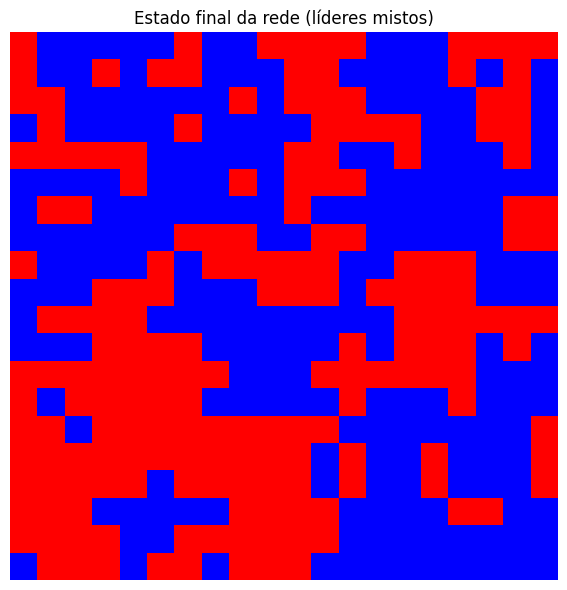

In [131]:
# Rede do estado final
plt.figure(figsize=(6, 6))
plt.imshow(state, cmap='bwr', interpolation='nearest')
plt.title("Estado final da rede (líderes mistos)")
plt.axis('off')
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** O número de crentes oscila ao longo do tempo, sem convergir para um consenso claro. A presença de líderes com opiniões opostas gera uma tensão constante na rede. O sistema parece buscar equilíbrio, mas sem estabilidade — refletindo uma sociedade polarizada.

### Teste 5: população com líderes crentes e temperaturas sociais diferentes

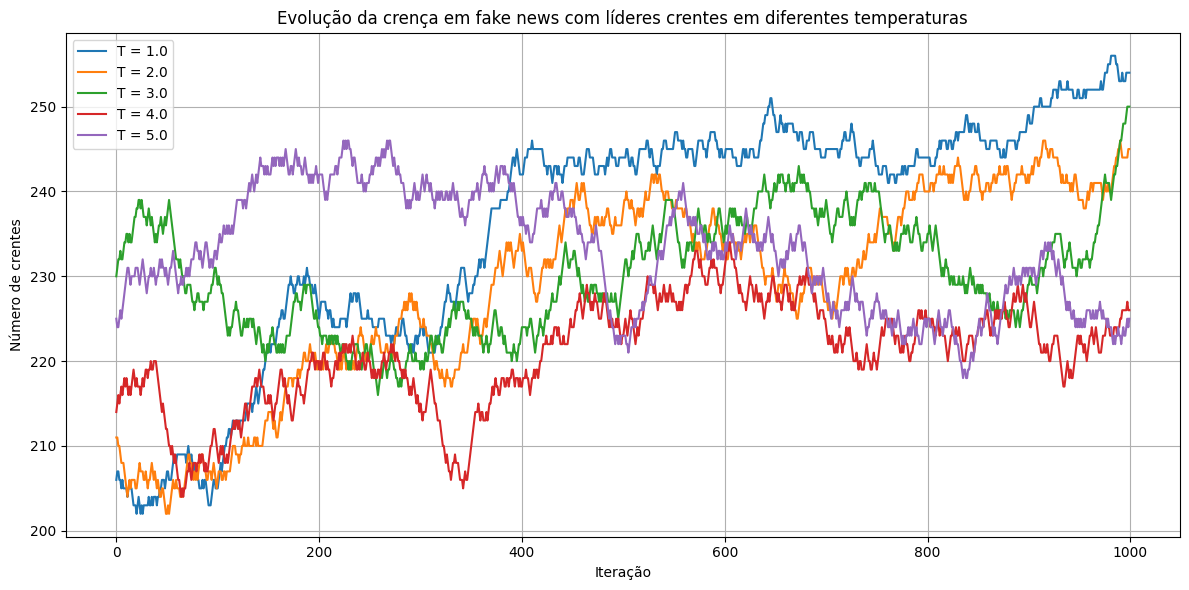

In [132]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
temperatures = [1.0, 2.0, 3.0, 4.0, 5.0]
iterations = 1000

# Ajuda para definir vizinhos em uma rede 2D com as condições
def get_neighbors(i, j, size):
    return [((i-1)%size, j), ((i+1)%size, j), (i, (j-1)%size), (i, (j+1)%size)]

# Função de simulação
def simulate_with_believer_leaders(temp):
    grid = np.random.choice([0, 1], size=(grid_size, grid_size))
    fixed = np.zeros((grid_size, grid_size), dtype=bool)

    # Define líderes crentes
    num_leaders = int(num_nodes * leader_fraction)
    leader_indices = random.sample(range(num_nodes), num_leaders)
    for idx in leader_indices:
        i, j = divmod(idx, grid_size)
        grid[i, j] = 1
        fixed[i, j] = True

    believers_over_time = []

    for _ in range(iterations):
        i, j = random.randint(0, grid_size-1), random.randint(0, grid_size-1)
        if fixed[i, j]:
            believers_over_time.append(np.sum(grid))
            continue

        current = grid[i, j]
        proposed = 1 - current

        neighbors = get_neighbors(i, j, grid_size)
        influence_current = sum(grid[ni, nj] == current for ni, nj in neighbors)
        influence_proposed = sum(grid[ni, nj] == proposed for ni, nj in neighbors)
        delta_E = influence_current - influence_proposed

        if delta_E <= 0 or random.random() < np.exp(-delta_E / temp):
            grid[i, j] = proposed

        believers_over_time.append(np.sum(grid))

    return believers_over_time

# Simulação para cada temperatura
results = {}
for T in temperatures:
    results[T] = simulate_with_believer_leaders(T)

# Visualização
plt.figure(figsize=(12, 6))
for T in temperatures:
    plt.plot(results[T], label=f"T = {T}")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença em fake news com líderes crentes em diferentes temperaturas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

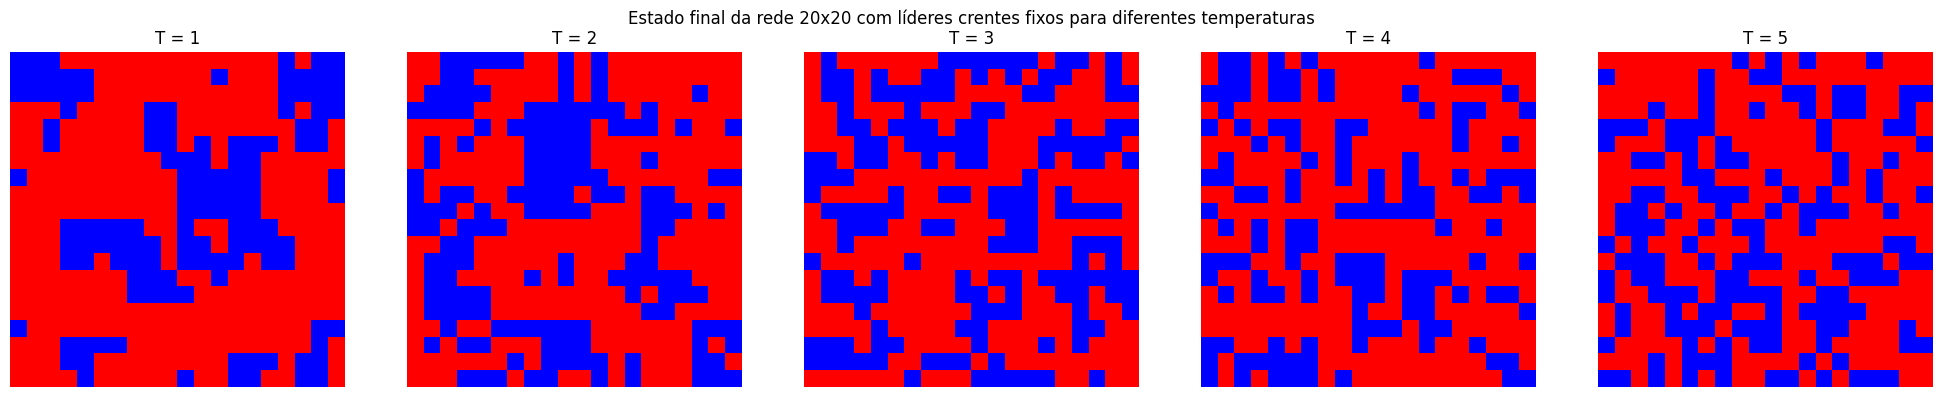

In [133]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
iterations = 1000

# Ajuda para definir vizinhos em uma rede 2D com as condições
def get_neighbors(i, j, size):
    return [((i-1)%size, j), ((i+1)%size, j), (i, (j-1)%size), (i, (j+1)%size)]

# Função de simulação
def simulate_ising_with_believer_leaders(temp):
    state = np.random.choice([0, 1], size=(grid_size, grid_size))
    fixed = np.zeros((grid_size, grid_size), dtype=bool)

    # Define os líderes crentes fixos
    num_leaders = int(num_nodes * leader_fraction)
    leader_indices = np.random.choice(num_nodes, num_leaders, replace=False)
    for idx in leader_indices:
        i, j = divmod(idx, grid_size)
        state[i, j] = 1
        fixed[i, j] = True

    for _ in range(iterations):
        i, j = np.random.randint(0, grid_size, size=2)
        if fixed[i, j]:
            continue
        current = state[i, j]
        proposed = 1 - current
        delta_E = 0
        for ni, nj in get_neighbors(i, j, grid_size):
            delta_E += (2 * current - 1) * (2 * state[ni, nj] - 1)
        if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / temp):
            state[i, j] = proposed

    return state

# Simulação para cada temperatura
final_states = []
for T in temperaturas:
    final_state = simulate_ising_with_believer_leaders(T)
    final_states.append(final_state)

# Visualização dos mapas das redes
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for ax, state, T in zip(axes, final_states, temperaturas):
    ax.imshow(state, cmap='bwr', vmin=0, vmax=1)
    ax.set_title(f"T = {T}")
    ax.axis('off')

plt.suptitle("Estado final da rede 20x20 com líderes crentes fixos para diferentes temperaturas")
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** Líderes crentes têm um papel significativo na propagação da fake news, especialmente em ambientes sociais com baixa ou média temperatura. Em sociedades mais voláteis (alta temperatura), a crença se torna mais instável, mesmo com líderes influentes.

### Teste 6: população com líderes céticos e temperaturas sociais diferentes

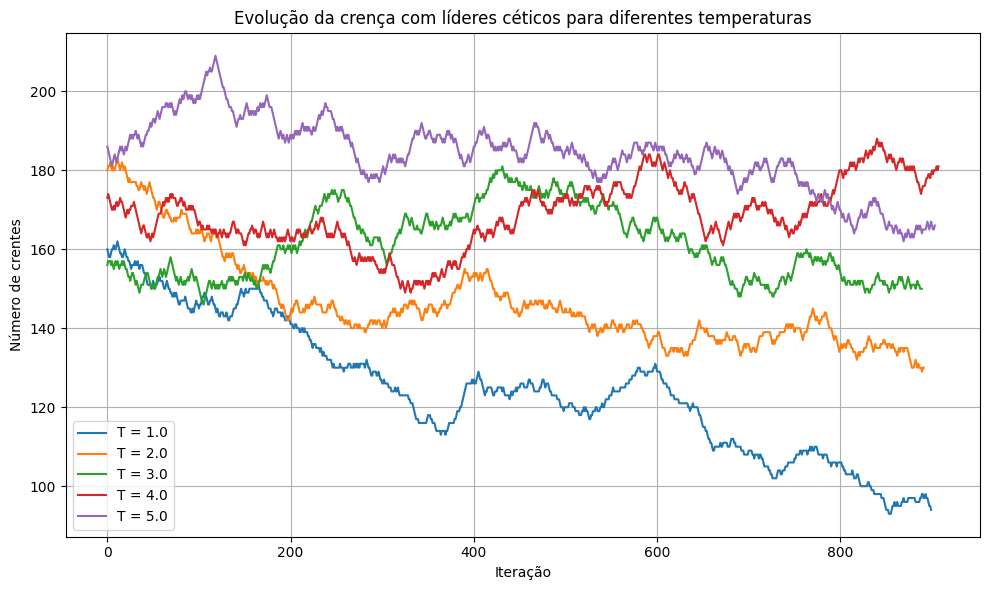

In [172]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
iterations = 1000

# Ajuda para definir vizinhos em uma rede 2D com as condições
def get_neighbors(i, j, size):
    return [((i-1)%size, j), ((i+1)%size, j), (i, (j-1)%size), (i, (j+1)%size)]

# Função de simulação
def simulate_with_skeptic_leaders(T):
    state = np.random.choice([0, 1], size=(grid_size, grid_size))
    num_leaders = int(num_nodes * leader_fraction)
    leader_indices = np.random.choice(num_nodes, num_leaders, replace=False)
    leader_coords = [(idx // grid_size, idx % grid_size) for idx in leader_indices]
    for i, j in leader_coords:
        state[i, j] = 0  
    fixed = np.zeros((grid_size, grid_size), dtype=bool)
    for i, j in leader_coords:
        fixed[i, j] = True

    believers_over_time = []

    for _ in range(iterations):
        i, j = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
        if fixed[i, j]:
            continue
        current = state[i, j]
        proposed = 1 - current
        delta_E = 0
        for ni, nj in get_neighbors(i, j, grid_size):
            delta_E += (2 * current - 1) * (2 * state[ni, nj] - 1)
        if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / T):
            state[i, j] = proposed
        believers_over_time.append(np.sum(state))

    return state, believers_over_time

# Simulação
final_states = {}
evolution_data = {}

for T in temperatures:
    final_state, believers = simulate_with_skeptic_leaders(T)
    final_states[T] = final_state
    evolution_data[T] = believers

# Visualização
plt.figure(figsize=(10, 6))
for T in temperatures:
    plt.plot(evolution_data[T], label=f"T = {T}")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença com líderes céticos para diferentes temperaturas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

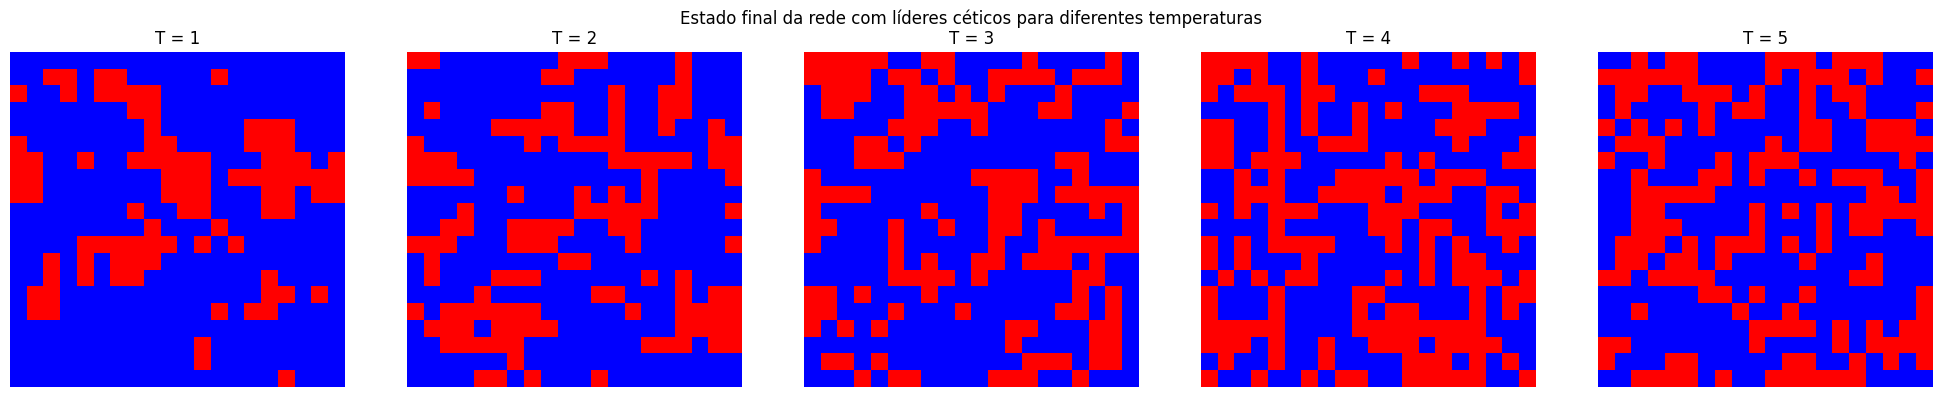

In [173]:
# Plotar mapas das redes
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for i, T in enumerate(temperaturas):
    axes[i].imshow(final_states[T], cmap='bwr', vmin=0, vmax=1)
    axes[i].set_title(f"T = {T}")
    axes[i].axis('off')
plt.suptitle("Estado final da rede com líderes céticos para diferentes temperaturas")
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** Em temperaturas baixas, o número de crentes rapidamente diminui e se estabiliza em um valor baixo — os líderes céticos dominam a dinâmica. Em médias, há mais flutuação, mas a tendência ainda é de contenção da fake news. Já em temperaturas altas, o número de crentes oscila mais, indicando que a influência dos líderes é parcialmente neutralizada pela aleatoriedade social.

### Teste 7: população com líderes mistos (crentes e céticos) e temperaturas sociais diferentes

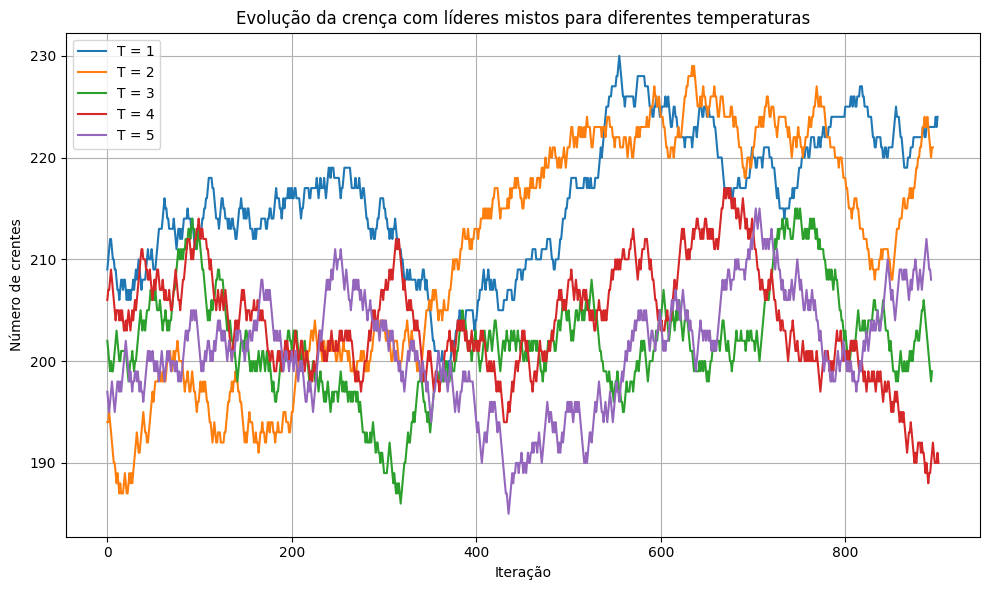

In [164]:
# Parâmetros
grid_size = 20
num_nodes = grid_size * grid_size
leader_fraction = 0.1
iterations = 1000

# Vizinhança para rede 2D (von Neumann)
neighbor_offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Ajuda para definir vizinhos em uma rede 2D com as condições
def get_neighbors(x, y, grid_size):
    return [((x + dx) % grid_size, (y + dy) % grid_size) for dx, dy in neighbor_offsets]

# Função de simulação
def simulate_mixed_leaders(temp):
    grid = np.random.choice([0, 1], size=(grid_size, grid_size))
    fixed = np.zeros((grid_size, grid_size), dtype=bool)

    # Definir líderes
    num_leaders = int(num_nodes * leader_fraction)
    leader_indices = np.random.choice(num_nodes, num_leaders, replace=False)
    half = num_leaders // 2
    for idx in leader_indices[:half]:
        x, y = divmod(idx, grid_size)
        grid[x, y] = 0  # skeptic
        fixed[x, y] = True
    for idx in leader_indices[half:]:
        x, y = divmod(idx, grid_size)
        grid[x, y] = 1  # believer
        fixed[x, y] = True

    belief_counts = []

    for _ in range(iterations):
        x, y = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
        if fixed[x, y]:
            continue
        current = grid[x, y]
        proposed = 1 - current
        neighbors = get_neighbors(x, y, grid_size)
        influence_current = sum(grid[nx, ny] == current for nx, ny in neighbors)
        influence_proposed = sum(grid[nx, ny] == proposed for nx, ny in neighbors)
        delta_E = influence_current - influence_proposed
        if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / temp):
            grid[x, y] = proposed
        belief_counts.append(np.sum(grid == 1))

    return belief_counts, grid

# Simulação
results = {}
final_grids = {}
for T in temperaturas:
    counts, final_grid = simulate_mixed_leaders(T)
    results[T] = counts
    final_grids[T] = final_grid

# Plotar evoluação de crença ao longo do tempo
plt.figure(figsize=(10, 6))
for T in temperaturas:
    plt.plot(results[T], label=f"T = {T}")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença com líderes mistos para diferentes temperaturas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

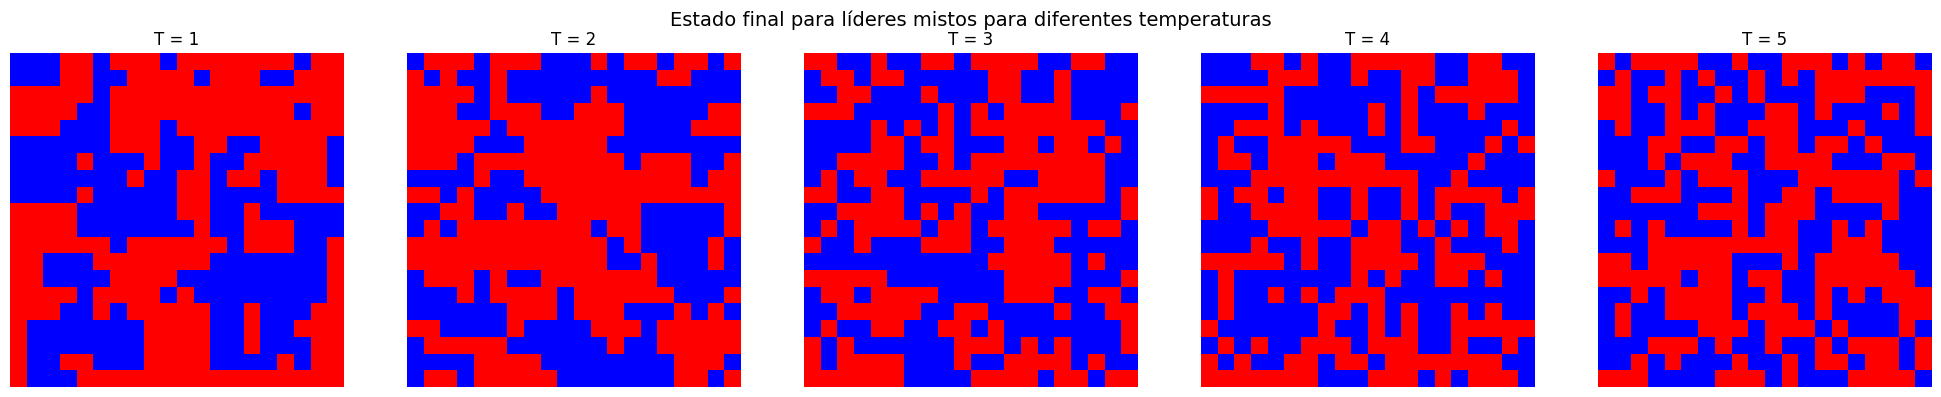

In [165]:
# Plotar estados finais
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for i, T in enumerate(temperaturas):
    axes[i].imshow(final_grids[T], cmap='bwr', vmin=0, vmax=1)
    axes[i].set_title(f"T = {T}")
    axes[i].axis('off')
plt.suptitle("Estado final para líderes mistos para diferentes temperaturas", fontsize=14)
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** Líderes mistos criam um ambiente de polarização estável, onde a crença na fake news nem domina nem desaparece.
A temperatura social atua como um amplificador da instabilidade: quanto maior, mais difícil é manter qualquer tipo de consenso.

### Teste 8: situação de consenso

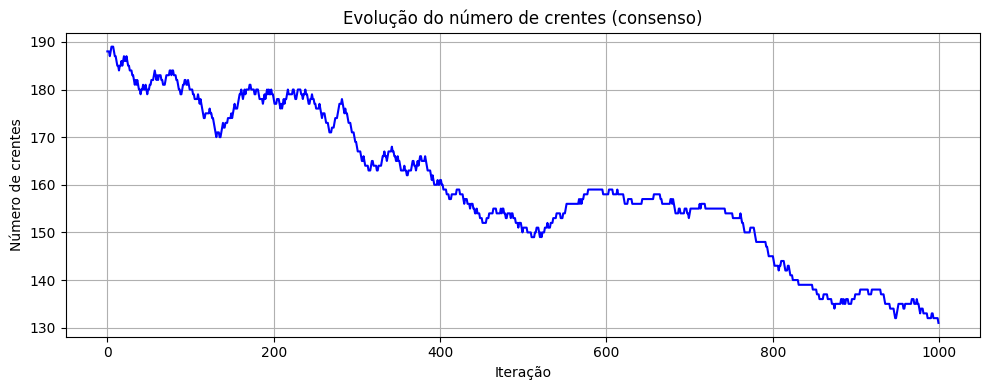

In [142]:
# Parâmetros
grid_size = 20
temperature = 0.5  # Baixa temperatura para consenso
iterations = 1000

# Inicializa rede com crença aleatória (0 or 1)
state = np.random.choice([0, 1], size=(grid_size, grid_size))

belief_counts = []

# Define função para computar mudança de energia
def delta_energy(state, x, y, proposed, T):
    current = state[x, y]
    neighbors = [
        state[(x-1)%grid_size, y],
        state[(x+1)%grid_size, y],
        state[x, (y-1)%grid_size],
        state[x, (y+1)%grid_size]
    ]
    influence_current = sum(1 if n == current else -1 for n in neighbors)
    influence_proposed = sum(1 if n == proposed else -1 for n in neighbors)
    return influence_current - influence_proposed

for _ in range(iterations):
    x, y = np.random.randint(0, grid_size, size=2)
    current = state[x, y]
    proposed = 1 - current
    dE = delta_energy(state, x, y, proposed, temperature)
    if dE <= 0 or np.random.rand() < np.exp(-dE / temperature):
        state[x, y] = proposed
    belief_counts.append(np.sum(state))

# Plotar evolução de crença
plt.figure(figsize=(10, 4))
plt.plot(belief_counts, color='blue')
plt.title("Evolução do número de crentes (consenso)")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.grid(True)
plt.tight_layout()
plt.show()

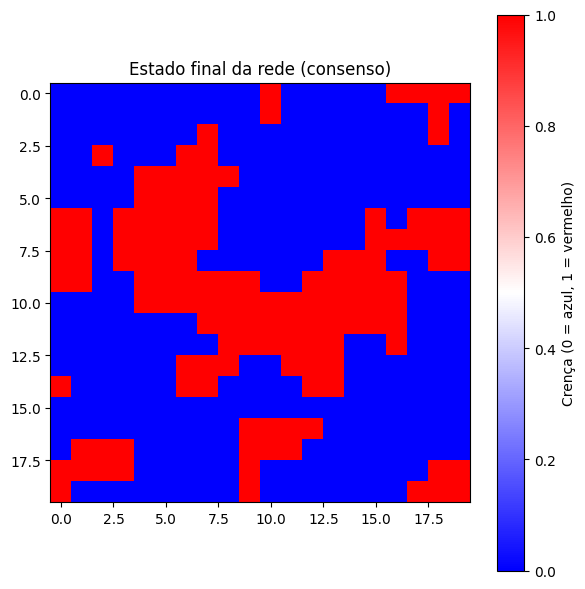

In [143]:
# Plotar estado final
plt.figure(figsize=(6, 6))
plt.imshow(state, cmap='bwr', interpolation='nearest')
plt.title("Estado final da rede (consenso)")
plt.colorbar(label='Crença (0 = azul, 1 = vermelho)')
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** Em ambientes sociais com baixa temperatura, a desinformação tende a persistir se já estiver amplamente difundida, ou o contrário, caso os céticos predominem. Por isso, o modelo mostra como o conformismo social pode sustentar crenças e descrenças.

### Teste 9: situação de consenso com temperaturas sociais diferentes

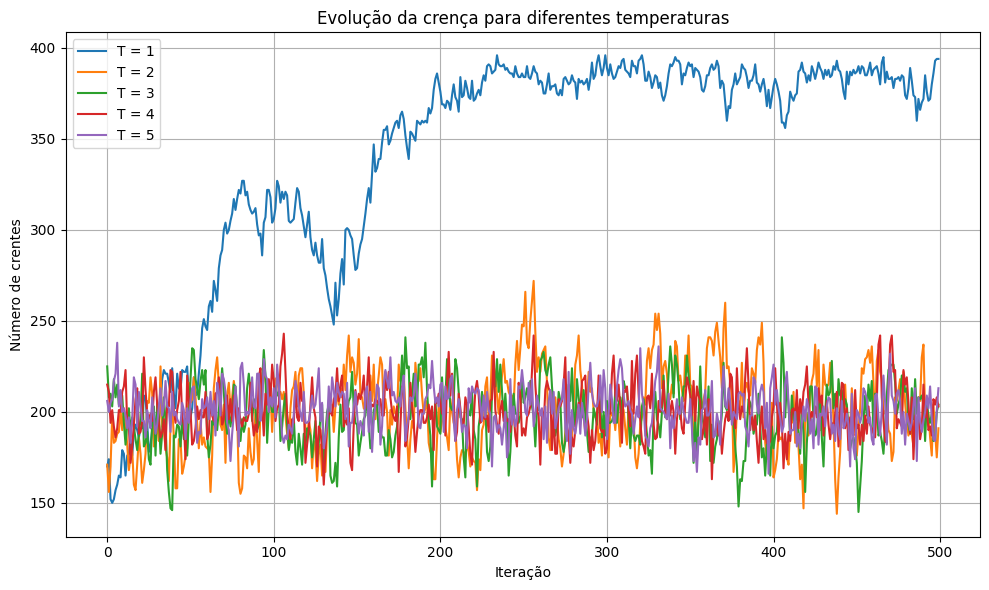

In [170]:
# Parâmetros
grid_size = 20
iterations = 500
leader_fraction = 0.0  # Sem líderes para consenso

# Simulação de Modelo Ising para rede 2D
def simulate_ising(grid_size, T, iterations):
    state = np.random.choice([0, 1], size=(grid_size, grid_size))
    belief_counts = []

    for _ in range(iterations):
        for _ in range(grid_size**2):
            i, j = np.random.randint(0, grid_size, size=2)
            current = state[i, j]
            proposed = 1 - current

            # Vizinhos
            neighbors = [
                state[(i-1)%grid_size, j],
                state[(i+1)%grid_size, j],
                state[i, (j-1)%grid_size],
                state[i, (j+1)%grid_size]
            ]
            influence_current = sum(n == current for n in neighbors)
            influence_proposed = sum(n == proposed for n in neighbors)
            delta_E = influence_current - influence_proposed

            if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / T):
                state[i, j] = proposed

        belief_counts.append(np.sum(state))

    return state, belief_counts

# Simulação
final_states = {}
belief_evolution = {}

for T in temperaturas:
    final_state, belief_counts = simulate_ising(grid_size, T, iterations)
    final_states[T] = final_state
    belief_evolution[T] = belief_counts

# Plotar evolução de crença
plt.figure(figsize=(10, 6))
for T in temperaturas:
    plt.plot(belief_evolution[T], label=f"T = {T}")
plt.xlabel("Iteração")
plt.ylabel("Número de crentes")
plt.title("Evolução da crença para diferentes temperaturas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

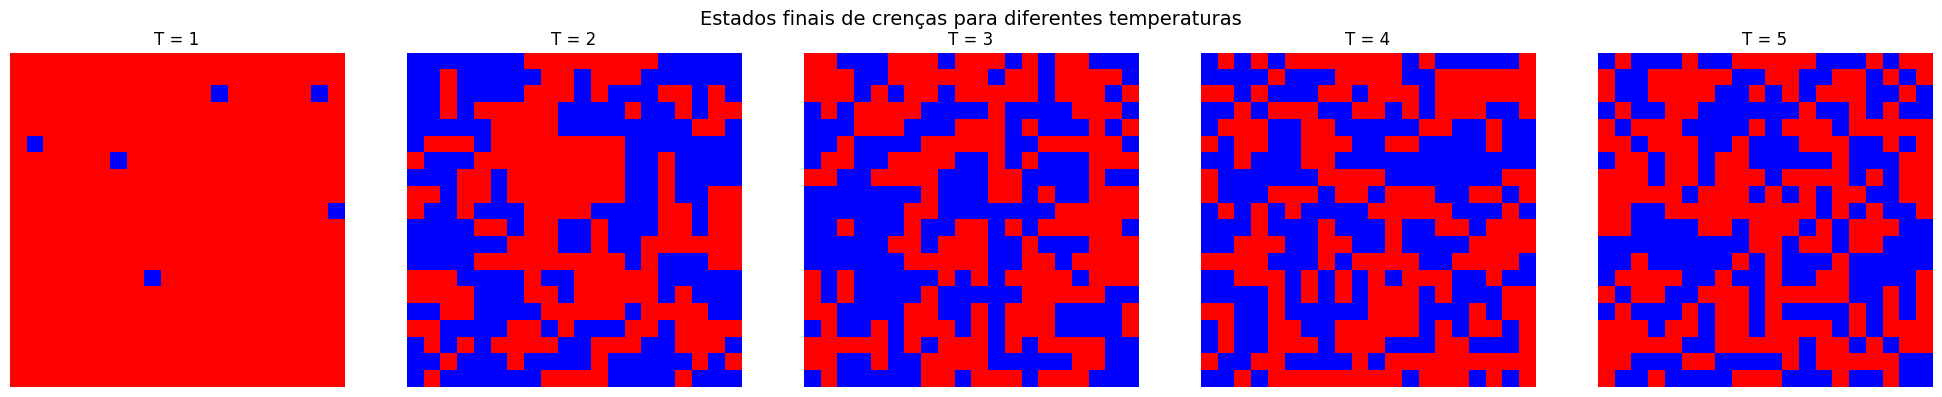

In [171]:
# Plotar mapas das redes
fig, axes = plt.subplots(1, len(temperaturas), figsize=(20, 4))
for idx, T in enumerate(temperaturas):
    ax = axes[idx]
    ax.imshow(final_states[T], cmap='bwr', vmin=0, vmax=1)
    ax.set_title(f"T = {T}")
    ax.axis('off')

plt.suptitle("Estados finais de crenças para diferentes temperaturas", fontsize=14)
plt.tight_layout()
plt.show()

🔍 **Interpretação dos Gráficos:** Em sociedades com baixa temperatura social, a desinformação tende a persistir se já estiver amplamente difundida.
À medida que a temperatura aumenta, a estabilidade do consenso diminui, permitindo que opiniões divergentes ganhem espaço.

---
## Conclusões

### Na difusão de Inovação ou Fake News via Spin-Flip...
Neste modelo, cada indivíduo em uma rede social é representado por um spin, que pode assumir dois estados:

- +1: acredita na inovação ou na fake news (opinião "sim")
- −1: não acredita (opinião "não")
  
A dinâmica de mudança de opinião segue métodos probabilísticos que permitem que indivíduos mudem de estado com base na influência de seus vizinhos e em um parâmetro chamado temperatura social.

Além disso, o modelo incorpora hubs ou líderes de opinião — nós com alto grau de conexão — que mantêm suas crenças fixas e influenciam fortemente os demais.

### Quando surge o consenso?
O consenso ocorre quando a maioria dos indivíduos compartilha a mesma opinião (todos os spins alinhados). Isso depende de:

- Temperatura social baixa: indivíduos tendem a seguir a maioria de seus vizinhos, favorecendo o alinhamento e o consenso.
- Presença de líderes fixos: se os líderes compartilham a mesma opinião, eles podem guiar a rede para um consenso estável.
- Estado inicial homogêneo: se todos começam acreditando, é mais provável que o sistema permaneça nesse estado.
### Qual o papel da temperatura social?
A temperatura social (T) controla o grau de aleatoriedade nas decisões individuais:

#### Em temperaturas baixas:
- Indivíduos resistem a mudar de opinião.
- O sistema tende a se estabilizar rapidamente.
- Consenso é comum, especialmente se houver líderes influentes.

#### Em temperaturas altas:
- Indivíduos mudam de opinião com mais facilidade, mesmo contra a maioria.
- O sistema se torna mais volátil e caótico.
- O consenso é difícil de alcançar; surgem flutuações e polarizações.

### Aplicações
Esse modelo pode ser usado para estudar:
- A propagação de inovações tecnológicas ou comportamentais.
- A disseminação de fake news em redes sociais.
- O impacto de influenciadores digitais na formação de opinião pública.
- A resiliência de uma sociedade à desinformação.